<a href="https://colab.research.google.com/github/nebjj/Solar_Generation_ML/blob/main/Solar_Production_Analysis_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anikannal/solar-power-generation-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'solar-power-generation-data' dataset.
Path to dataset files: /kaggle/input/solar-power-generation-data


In [ ]:
import os

print(os.listdir(path))

['Plant_2_Generation_Data.csv', 'Plant_2_Weather_Sensor_Data.csv', 'Plant_1_Weather_Sensor_Data.csv', 'Plant_1_Generation_Data.csv']


In [ ]:
import pandas as pd

plant1_gen = pd.read_csv(f"{path}/Plant_1_Generation_Data.csv")
plant1_weather = pd.read_csv(f"{path}/Plant_1_Weather_Sensor_Data.csv")

plant2_gen = pd.read_csv(f"{path}/Plant_2_Generation_Data.csv")
plant2_weather = pd.read_csv(f"{path}/Plant_2_Weather_Sensor_Data.csv")

In [ ]:
plant1_gen.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [ ]:
plant1_gen.describe()

,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,68778.0,68778.000000,68778.000000,68778.000000,6.877800e+04
mean,4135001.0,3147.426211,307.802752,3295.968737,6.978712e+06
std,0.0,4036.457169,394.396439,3145.178309,4.162720e+05
min,4135001.0,0.000000,0.000000,0.000000,6.183645e+06
25%,4135001.0,0.000000,0.000000,0.000000,6.512003e+06
50%,4135001.0,429.000000,41.493750,2658.714286,7.146685e+06
75%,4135001.0,6366.964286,623.618750,6274.000000,7.268706e+06
max,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06


In [ ]:
plant1_gen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.7+ MB


In [ ]:
plant1_gen.duplicated().sum()

np.int64(0)

In [ ]:
plant1_weather.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [ ]:
plant1_weather.describe()

,PLANT_ID,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,3182.0,3182.000000,3182.000000,3182.000000
mean,4135001.0,25.531606,31.091015,0.228313
std,0.0,3.354856,12.261222,0.300836
min,4135001.0,20.398505,18.140415,0.000000
25%,4135001.0,22.705182,21.090553,0.000000
50%,4135001.0,24.613814,24.618060,0.024653
75%,4135001.0,27.920532,41.307840,0.449588
max,4135001.0,35.252486,65.545714,1.221652


In [ ]:
plant1_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3182 non-null   object 
 1   PLANT_ID             3182 non-null   int64  
 2   SOURCE_KEY           3182 non-null   object 
 3   AMBIENT_TEMPERATURE  3182 non-null   float64
 4   MODULE_TEMPERATURE   3182 non-null   float64
 5   IRRADIATION          3182 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 149.3+ KB


In [ ]:
plant1_weather.duplicated().sum()

np.int64(0)

In [ ]:
plant2_gen.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,4136001,4UPUqMRk7TRMgml,0.0,0.0,9425.000000,2.429011e+06
1,2020-05-15 00:00:00,4136001,81aHJ1q11NBPMrL,0.0,0.0,0.000000,1.215279e+09
2,2020-05-15 00:00:00,4136001,9kRcWv60rDACzjR,0.0,0.0,3075.333333,2.247720e+09
3,2020-05-15 00:00:00,4136001,Et9kgGMDl729KT4,0.0,0.0,269.933333,1.704250e+06
4,2020-05-15 00:00:00,4136001,IQ2d7wF4YD8zU1Q,0.0,0.0,3177.000000,1.994153e+07


In [ ]:
plant2_gen.describe()

,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,67698.0,67698.000000,67698.000000,67698.000000,6.769800e+04
mean,4136001.0,246.701961,241.277825,3294.890295,6.589448e+08
std,0.0,370.569597,362.112118,2919.448386,7.296678e+08
min,4136001.0,0.000000,0.000000,0.000000,0.000000e+00
25%,4136001.0,0.000000,0.000000,272.750000,1.996494e+07
50%,4136001.0,0.000000,0.000000,2911.000000,2.826276e+08
75%,4136001.0,446.591667,438.215000,5534.000000,1.348495e+09
max,4136001.0,1420.933333,1385.420000,9873.000000,2.247916e+09


In [ ]:
plant2_gen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67698 entries, 0 to 67697
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    67698 non-null  object 
 1   PLANT_ID     67698 non-null  int64  
 2   SOURCE_KEY   67698 non-null  object 
 3   DC_POWER     67698 non-null  float64
 4   AC_POWER     67698 non-null  float64
 5   DAILY_YIELD  67698 non-null  float64
 6   TOTAL_YIELD  67698 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.6+ MB


In [ ]:
plant2_gen.duplicated().sum()

np.int64(0)

In [ ]:
plant2_weather.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4136001,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0
1,2020-05-15 00:15:00,4136001,iq8k7ZNt4Mwm3w0,26.880811,24.421869,0.0
2,2020-05-15 00:30:00,4136001,iq8k7ZNt4Mwm3w0,26.682055,24.427290,0.0
3,2020-05-15 00:45:00,4136001,iq8k7ZNt4Mwm3w0,26.500589,24.420678,0.0
4,2020-05-15 01:00:00,4136001,iq8k7ZNt4Mwm3w0,26.596148,25.088210,0.0


In [ ]:
plant2_weather.describe()

,PLANT_ID,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,3259.0,3259.000000,3259.000000,3259.000000
mean,4136001.0,28.069400,32.772408,0.232737
std,0.0,4.061556,11.344034,0.312693
min,4136001.0,20.942385,20.265123,0.000000
25%,4136001.0,24.602135,23.716881,0.000000
50%,4136001.0,26.981263,27.534606,0.019040
75%,4136001.0,31.056757,40.480653,0.438717
max,4136001.0,39.181638,66.635953,1.098766


In [ ]:
plant2_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3259 entries, 0 to 3258
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3259 non-null   object 
 1   PLANT_ID             3259 non-null   int64  
 2   SOURCE_KEY           3259 non-null   object 
 3   AMBIENT_TEMPERATURE  3259 non-null   float64
 4   MODULE_TEMPERATURE   3259 non-null   float64
 5   IRRADIATION          3259 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 152.9+ KB


In [ ]:
plant2_weather.duplicated().sum()

np.int64(0)

So, none of the datasets has duplicated rows. All are non-null, unique rows. Total number of rows in all datasets are different.

In [ ]:
#checking unique timestamps
print(plant1_gen["DATE_TIME"].nunique())

3158


In [ ]:
print(plant1_weather["DATE_TIME"].nunique())

3182


In [ ]:
#lets check unique source keys too
print(plant1_gen["SOURCE_KEY"].nunique())

22


In [ ]:
print(plant1_weather["SOURCE_KEY"].nunique())

1


In [ ]:
for df in [plant1_gen, plant1_weather, plant2_gen, plant2_weather]:
    df["DATE_TIME"] = pd.to_datetime(
        df["DATE_TIME"],
        dayfirst=True
    )

/tmp/ipykernel_1085/3552365184.py:2: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["DATE_TIME"] = pd.to_datetime(
/tmp/ipykernel_1085/3552365184.py:2: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["DATE_TIME"] = pd.to_datetime(
/tmp/ipykernel_1085/3552365184.py:2: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["DATE_TIME"] = pd.to_datetime(


In [ ]:
plant1_gen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE_TIME    68778 non-null  datetime64[ns]
 1   PLANT_ID     68778 non-null  int64         
 2   SOURCE_KEY   68778 non-null  object        
 3   DC_POWER     68778 non-null  float64       
 4   AC_POWER     68778 non-null  float64       
 5   DAILY_YIELD  68778 non-null  float64       
 6   TOTAL_YIELD  68778 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 3.7+ MB


In [ ]:
plant1_gen.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [ ]:
plant1_gen["DATE_TIME"] = pd.to_datetime(plant1_gen["DATE_TIME"])

plant1_weather["DATE_TIME"] = pd.to_datetime(
    plant1_weather["DATE_TIME"]
)

plant2_gen["DATE_TIME"] = pd.to_datetime(plant2_gen["DATE_TIME"])

plant2_weather["DATE_TIME"] = pd.to_datetime(
    plant2_weather["DATE_TIME"]
)

In [ ]:
plant1 = plant1_gen.merge(
    plant1_weather,
    on=["DATE_TIME","PLANT_ID"],
    how="inner"
)

plant2 = plant2_gen.merge(
    plant2_weather,
    on=["DATE_TIME","PLANT_ID"],
    how="inner"
)

In [ ]:
df = pd.concat([plant1, plant2])

In [ ]:
df.shape

(136472, 11)

In [ ]:
df.columns

Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY_x', 'DC_POWER', 'AC_POWER',
       'DAILY_YIELD', 'TOTAL_YIELD', 'SOURCE_KEY_y', 'AMBIENT_TEMPERATURE',
       'MODULE_TEMPERATURE', 'IRRADIATION'],
      dtype='object')

In [ ]:
df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


In [ ]:
df.tail()

,DATE_TIME,PLANT_ID,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
67693,2020-06-17 23:45:00,4136001,q49J1IKaHRwDQnt,0.0,0.0,4157.0,520758.0,iq8k7ZNt4Mwm3w0,23.202871,22.535908,0.0
67694,2020-06-17 23:45:00,4136001,rrq4fwE8jgrTyWY,0.0,0.0,3931.0,121131356.0,iq8k7ZNt4Mwm3w0,23.202871,22.535908,0.0
67695,2020-06-17 23:45:00,4136001,vOuJvMaM2sgwLmb,0.0,0.0,4322.0,2427691.0,iq8k7ZNt4Mwm3w0,23.202871,22.535908,0.0
67696,2020-06-17 23:45:00,4136001,xMbIugepa2P7lBB,0.0,0.0,4218.0,106896394.0,iq8k7ZNt4Mwm3w0,23.202871,22.535908,0.0
67697,2020-06-17 23:45:00,4136001,xoJJ8DcxJEcupym,0.0,0.0,4316.0,209335741.0,iq8k7ZNt4Mwm3w0,23.202871,22.535908,0.0


In [ ]:
df.isnull().sum()

,0
DATE_TIME,0
PLANT_ID,0
SOURCE_KEY_x,0
DC_POWER,0
AC_POWER,0
DAILY_YIELD,0
TOTAL_YIELD,0
SOURCE_KEY_y,0
AMBIENT_TEMPERATURE,0
MODULE_TEMPERATURE,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 136472 entries, 0 to 67697
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   DATE_TIME            136472 non-null  datetime64[ns]
 1   PLANT_ID             136472 non-null  int64         
 2   SOURCE_KEY_x         136472 non-null  object        
 3   DC_POWER             136472 non-null  float64       
 4   AC_POWER             136472 non-null  float64       
 5   DAILY_YIELD          136472 non-null  float64       
 6   TOTAL_YIELD          136472 non-null  float64       
 7   SOURCE_KEY_y         136472 non-null  object        
 8   AMBIENT_TEMPERATURE  136472 non-null  float64       
 9   MODULE_TEMPERATURE   136472 non-null  float64       
 10  IRRADIATION          136472 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(1), object(2)
memory usage: 12.5+ MB


In [ ]:
df["PLANT_ID"].value_counts()

,count
PLANT_ID,
4135001,68774
4136001,67698


In [ ]:
df.describe()

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,136472,1.364720e+05,136472.000000,136472.000000,136472.000000,1.364720e+05,136472.000000,136472.000000,136472.000000
mean,2020-06-01 09:22:57.605662464,4.135497e+06,1708.373962,274.790259,3295.366192,3.303916e+08,26.763066,31.920744,0.230767
min,2020-05-15 00:00:00,4.135001e+06,0.000000,0.000000,0.000000,0.000000e+00,20.398505,18.140415,0.000000
25%,2020-05-23 23:00:00,4.135001e+06,0.000000,0.000000,28.285714,6.520020e+06,23.637604,22.411698,0.000000
50%,2020-06-01 18:45:00,4.135001e+06,5.993333,3.493095,2834.642857,7.269333e+06,25.908122,26.413755,0.026213
75%,2020-06-09 21:45:00,4.136001e+06,1155.595000,532.568571,5992.000000,2.826096e+08,29.266583,40.778583,0.442961
max,2020-06-17 23:45:00,4.136001e+06,14471.125000,1410.950000,9873.000000,2.247916e+09,39.181638,66.635953,1.221652
std,NaN,4.999863e+02,3222.079306,380.180214,3035.313217,6.085769e+08,3.897340,11.803674,0.305652


In [ ]:
df.describe().round(2)

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,136472,136472.00,136472.00,136472.00,136472.00,1.364720e+05,136472.00,136472.00,136472.00
mean,2020-06-01 09:22:57.605662464,4135497.06,1708.37,274.79,3295.37,3.303916e+08,26.76,31.92,0.23
min,2020-05-15 00:00:00,4135001.00,0.00,0.00,0.00,0.000000e+00,20.40,18.14,0.00
25%,2020-05-23 23:00:00,4135001.00,0.00,0.00,28.29,6.520020e+06,23.64,22.41,0.00
50%,2020-06-01 18:45:00,4135001.00,5.99,3.49,2834.64,7.269333e+06,25.91,26.41,0.03
75%,2020-06-09 21:45:00,4136001.00,1155.59,532.57,5992.00,2.826096e+08,29.27,40.78,0.44
max,2020-06-17 23:45:00,4136001.00,14471.12,1410.95,9873.00,2.247916e+09,39.18,66.64,1.22
std,NaN,499.99,3222.08,380.18,3035.31,6.085769e+08,3.90,11.80,0.31




*   Median is smaller than mean for both AC and DC
*   Data is highly skewed


*   Ambient Temperature - in between 20 and 40 degrees
*   Module Temperature - in between 18 and 67 degrees





In [ ]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

DATE_TIME: 3262
PLANT_ID: 2
SOURCE_KEY_x: 44
DC_POWER: 63604
AC_POWER: 62912
DAILY_YIELD: 59306
TOTAL_YIELD: 70378
SOURCE_KEY_y: 2
AMBIENT_TEMPERATURE: 6416
MODULE_TEMPERATURE: 6416
IRRADIATION: 3617


In [ ]:
df.rename(
    columns={
        "SOURCE_KEY_x": "INVERTER_ID",
        "SOURCE_KEY_y": "WEATHER_STATION_ID"
    },
    inplace=True
)

In [ ]:
df["INVERTER_ID"].value_counts().head()

,count
INVERTER_ID,
LlT2YUhhzqhg5Sw,3259
vOuJvMaM2sgwLmb,3259
oZZkBaNadn6DNKz,3259
q49J1IKaHRwDQnt,3259
xoJJ8DcxJEcupym,3259


In [ ]:
df["WEATHER_STATION_ID"].value_counts()

,count
WEATHER_STATION_ID,
HmiyD2TTLFNqkNe,68774
iq8k7ZNt4Mwm3w0,67698


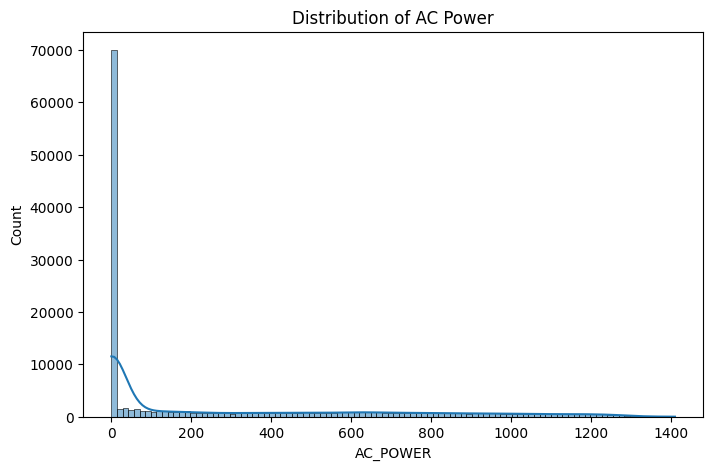

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df["AC_POWER"], bins=100, kde=True)

plt.title("Distribution of AC Power")

plt.show()

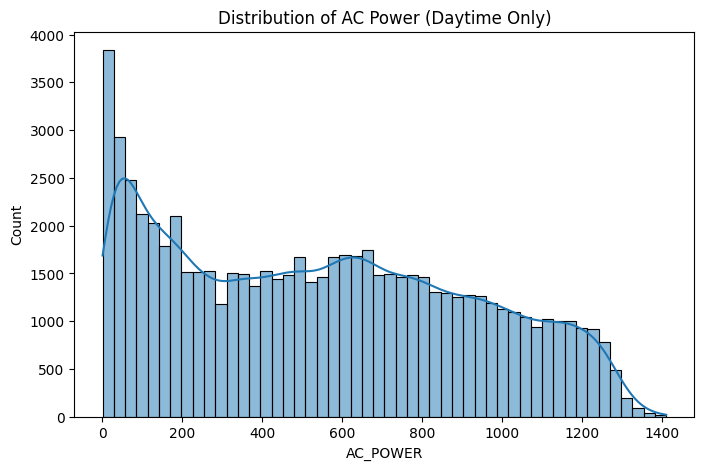

In [ ]:
ac_day = df[df["AC_POWER"] > 0]

plt.figure(figsize=(8,5))

sns.histplot(ac_day["AC_POWER"], bins=50, kde=True)

plt.title("Distribution of AC Power (Daytime Only)")

plt.show()

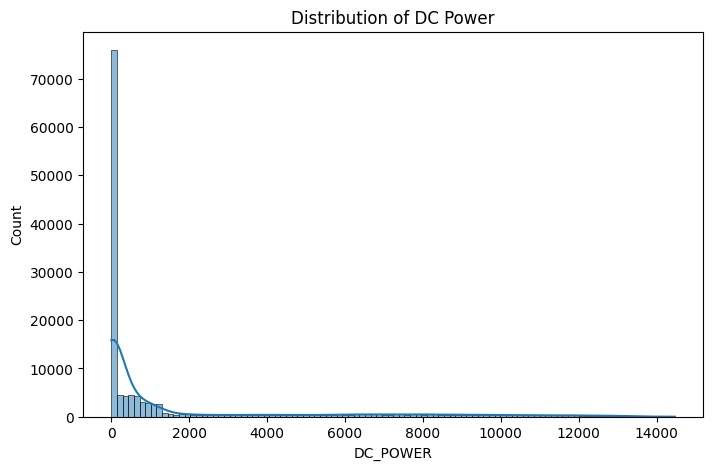

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["DC_POWER"], bins=100, kde=True)

plt.title("Distribution of DC Power")

plt.show()

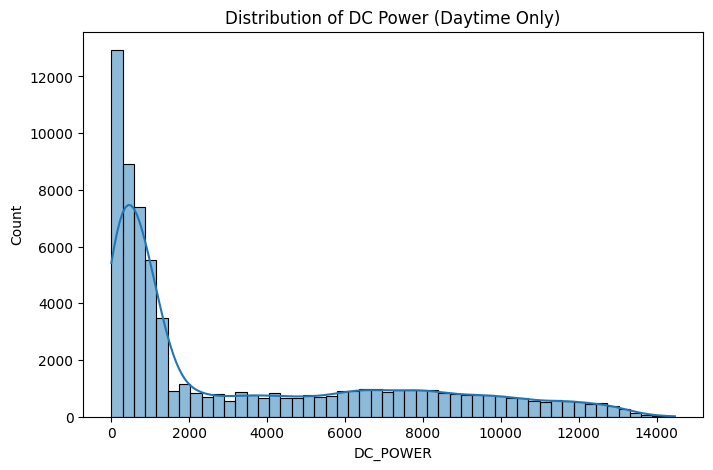

In [ ]:
dc_day = df[df["DC_POWER"] > 0]

plt.figure(figsize=(8,5))

sns.histplot(ac_day["DC_POWER"], bins=50, kde=True)

plt.title("Distribution of DC Power (Daytime Only)")

plt.show()

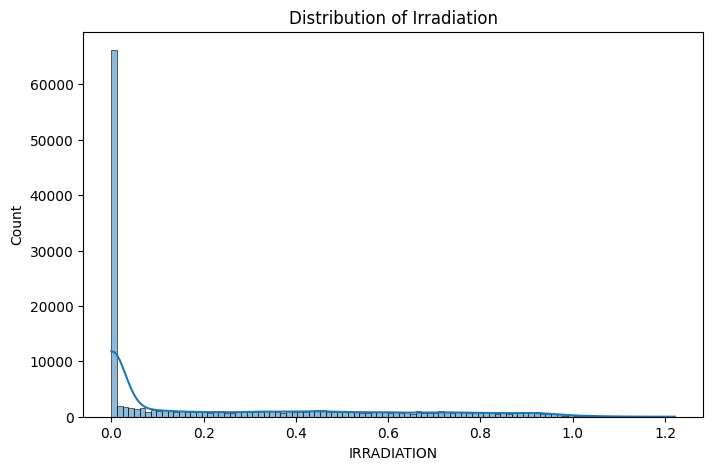

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["IRRADIATION"], bins=100, kde=True)

plt.title("Distribution of Irradiation")

plt.show()

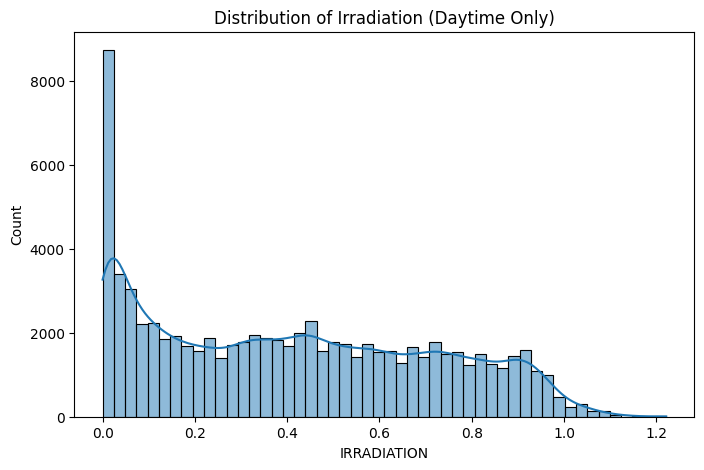

In [ ]:
ac_day = df[df["IRRADIATION"] > 0]

plt.figure(figsize=(8,5))

sns.histplot(ac_day["IRRADIATION"], bins=50, kde=True)

plt.title("Distribution of Irradiation (Daytime Only)")

plt.show()

<Axes: xlabel='MODULE_TEMPERATURE', ylabel='Count'>

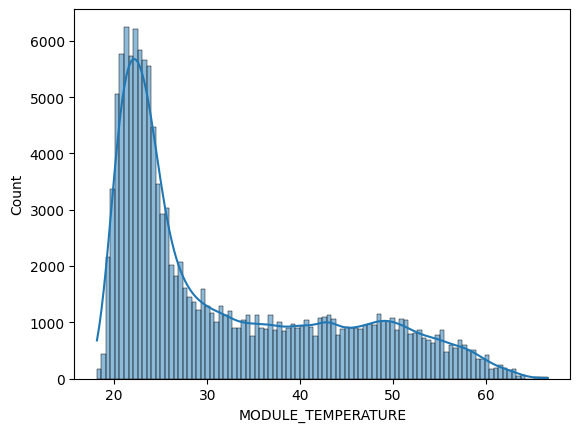

In [ ]:
sns.histplot(df["MODULE_TEMPERATURE"], bins=100, kde=True)

<Axes: xlabel='AMBIENT_TEMPERATURE', ylabel='Count'>

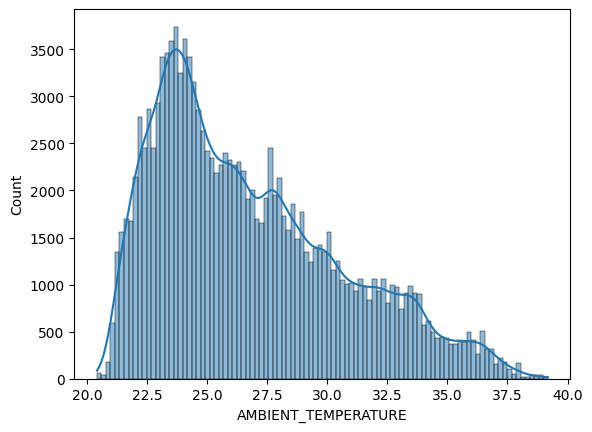

In [ ]:
sns.histplot(df["AMBIENT_TEMPERATURE"], bins=100, kde=True)

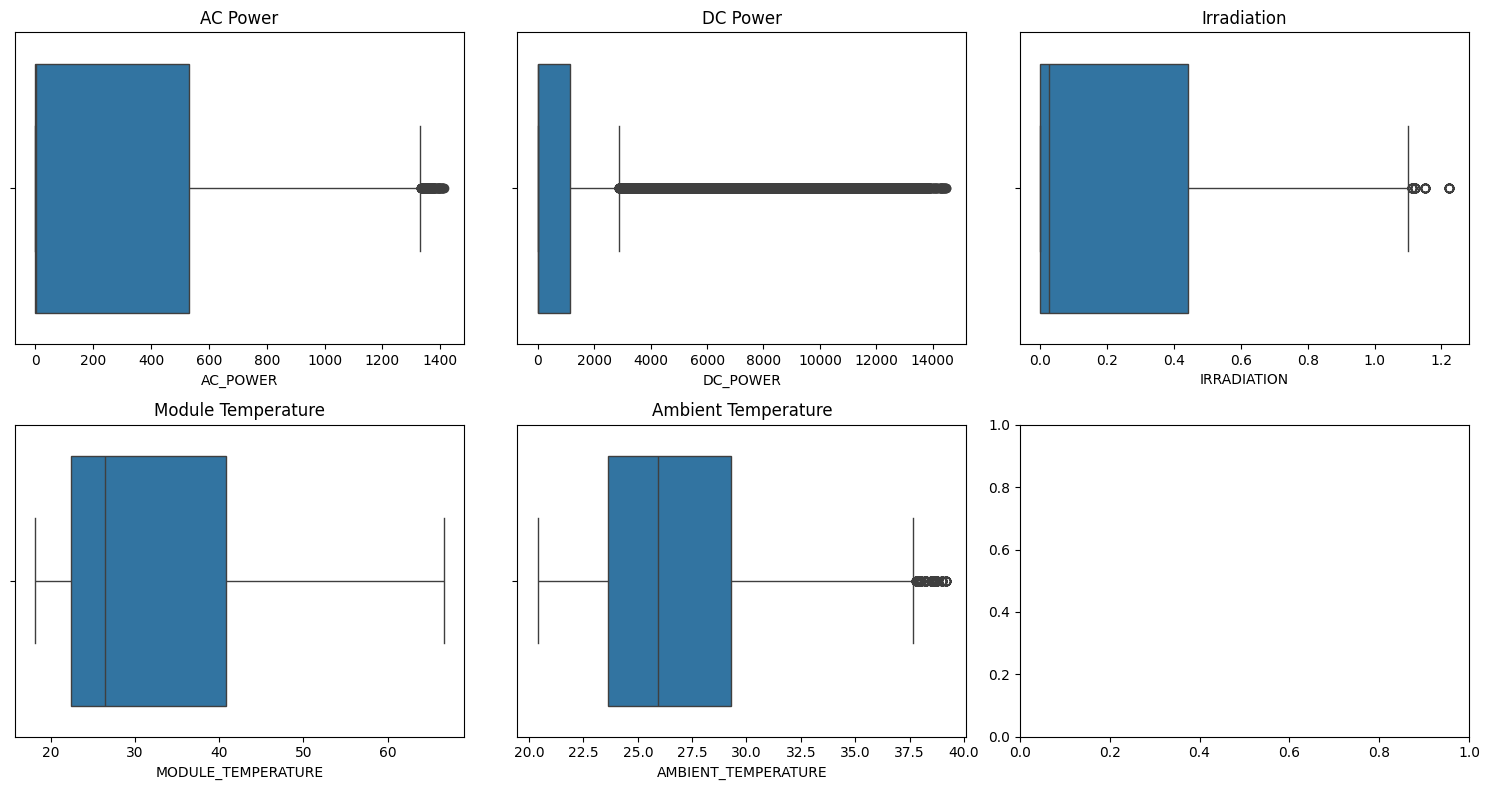

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.boxplot(x=df["AC_POWER"], ax=axes[0,0])
axes[0,0].set_title("AC Power")

sns.boxplot(x=df["DC_POWER"], ax=axes[0,1])
axes[0,1].set_title("DC Power")

sns.boxplot(x=df["IRRADIATION"], ax=axes[0,2])
axes[0,2].set_title("Irradiation")

sns.boxplot(x=df["MODULE_TEMPERATURE"], ax=axes[1,0])
axes[1,0].set_title("Module Temperature")

sns.boxplot(x=df["AMBIENT_TEMPERATURE"], ax=axes[1,1])
axes[1,1].set_title("Ambient Temperature")

plt.tight_layout()
plt.show()

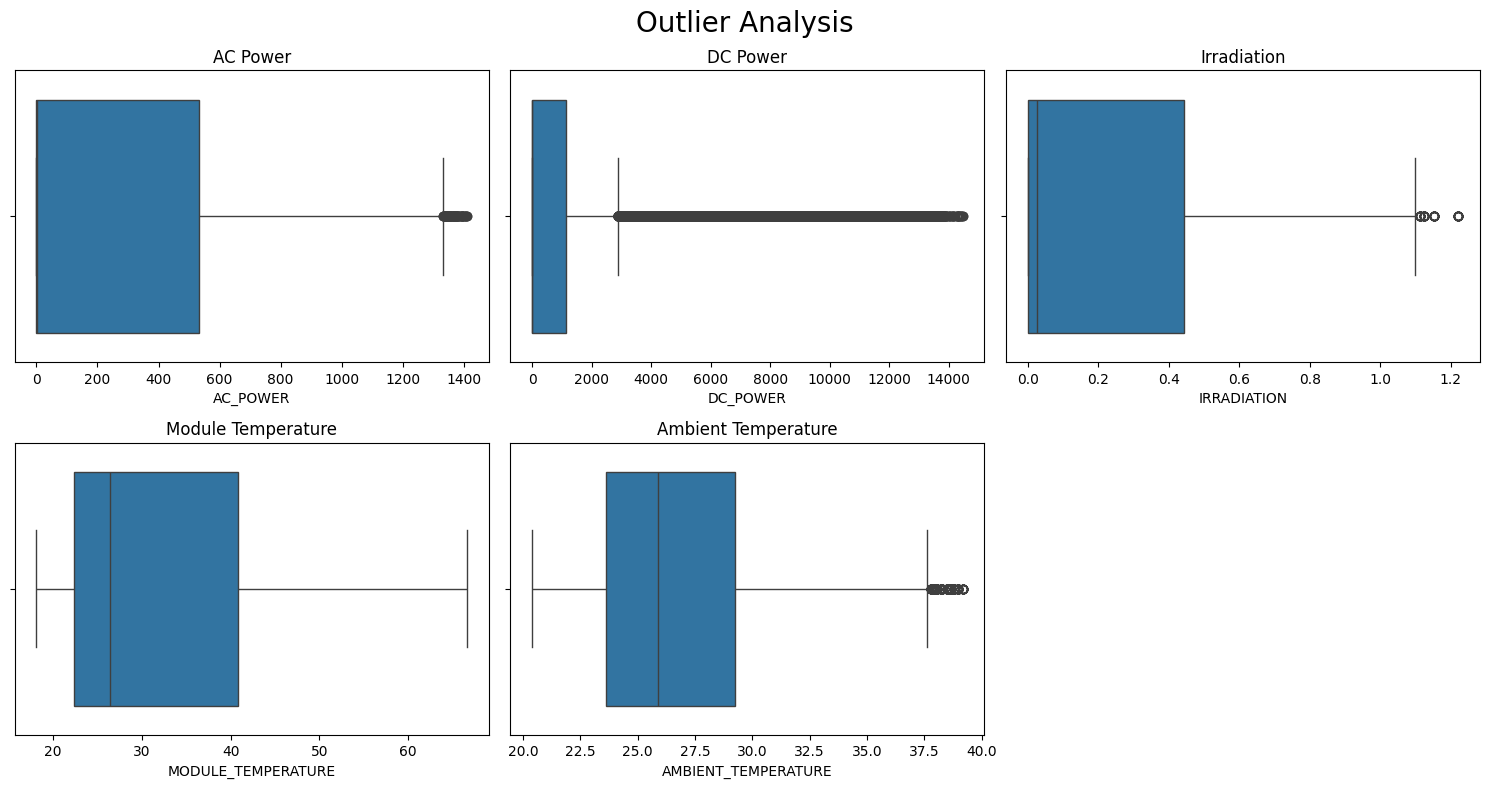

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.boxplot(x=df["AC_POWER"], ax=axes[0,0])
axes[0,0].set_title("AC Power")

sns.boxplot(x=df["DC_POWER"], ax=axes[0,1])
axes[0,1].set_title("DC Power")

sns.boxplot(x=df["IRRADIATION"], ax=axes[0,2])
axes[0,2].set_title("Irradiation")

sns.boxplot(x=df["MODULE_TEMPERATURE"], ax=axes[1,0])
axes[1,0].set_title("Module Temperature")

sns.boxplot(x=df["AMBIENT_TEMPERATURE"], ax=axes[1,1])
axes[1,1].set_title("Ambient Temperature")

#removing last figure
fig.delaxes(axes[1,2])

# leaving space for the title
plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.suptitle("Outlier Analysis", fontsize=20)

plt.show()


1.   AC Power: having outliers, but it's just some peak productions
2.   DC Power: more extreme outliers, but it is due to higher DC output.


1.   Irradition: A few high outliers, which could correspond to very sunny conditions.
2.   Module_temp: No significant outliers.


1.   Ambient temp: A few high-temperature outliers (around 38–39°C), which are realistic in hot climates.












In [ ]:
(df["DC_POWER"] / df["AC_POWER"]).describe()

,0
count,68859.000000
mean,5.948850
std,4.593976
min,0.991749
25%,1.022391
50%,10.182843
75%,10.223038
max,10.465522


In [ ]:
df[df["AC_POWER"] > 0][["DC_POWER", "AC_POWER"]].sample(10)

,DC_POWER,AC_POWER
35758,82.750000,7.975000
65928,4308.000000,422.842857
32633,830.593333,812.873333
2785,398.740000,391.700000
54452,94.850000,92.142857
35337,319.566667,312.720000
52960,8703.875000,850.800000
9064,332.406667,326.513333
7383,7624.428571,746.385714
48583,12390.750000,1208.100000


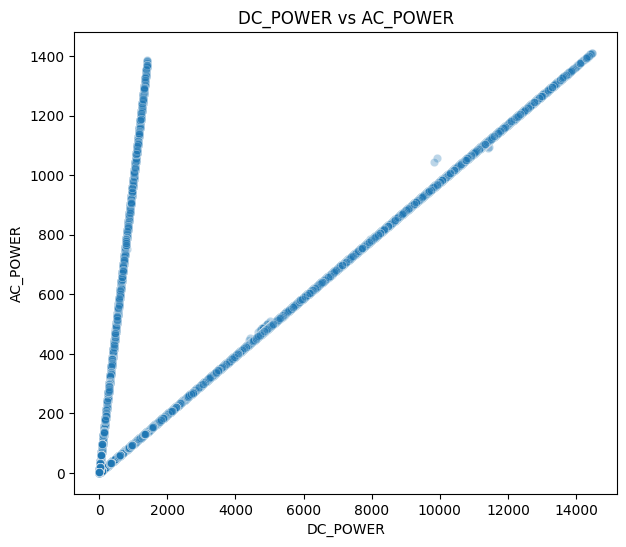

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

sns.scatterplot(
    data=df[df["AC_POWER"] > 0],
    x="DC_POWER",
    y="AC_POWER",
    alpha=0.3
)

plt.title("DC_POWER vs AC_POWER")
plt.show()

So, there exists 2 AC-DC Relationship:


1.   One with ratio almost equals 1
2.   Another one has ratio closer to 10



In [ ]:
df.groupby("PLANT_ID")[["DC_POWER", "AC_POWER"]].describe()

DC_POWER                                                  \
            count         mean          std  min  25%         50%   
PLANT_ID                                                            
4135001   68774.0  3147.177450  4036.441826  0.0  0.0  428.571429   
4136001   67698.0   246.701961   370.569597  0.0  0.0    0.000000   

                                    AC_POWER                               \
                  75%           max    count        mean         std  min   
PLANT_ID                                                                    
4135001   6365.468750  14471.125000  68774.0  307.778375  394.394865  0.0   
4136001    446.591667   1420.933333  67698.0  241.277825  362.112118  0.0   

                                           
          25%    50%         75%      max  
PLANT_ID                                   
4135001   0.0  41.45  623.561161  1410.95  
4136001   0.0   0.00  438.215000  1385.42

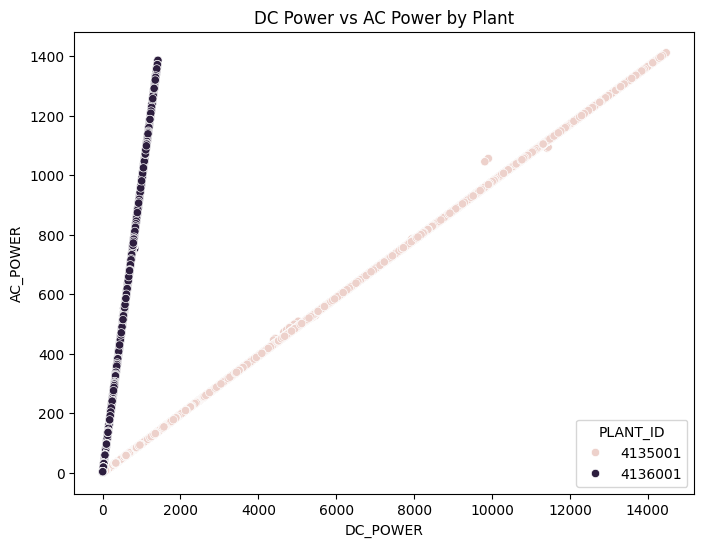

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df[df["AC_POWER"] > 0],
    x="DC_POWER",
    y="AC_POWER",
    hue="PLANT_ID"
)

plt.title("DC Power vs AC Power by Plant")
plt.show()

DC-AC Ratio change is depended on plants

In [ ]:
avg_ac = (
    df.groupby(["PLANT_ID", "INVERTER_ID"])["AC_POWER"]
      .mean()
      .sort_values(ascending=False)
)

print(avg_ac)

PLANT_ID  INVERTER_ID    
4135001   adLQvlD726eNBSB    319.570159
          1IF53ai7Xc0U56Y    315.369260
          3PZuoBAID5Wc2HD    314.967354
          McdE0feGgRqW7Ca    314.046321
          VHMLBKoKgIrUVDU    313.900096
          iCRJl6heRkivqQ3    312.540320
          uHbuxQJl8lW7ozc    312.467844
          ZnxXDlPa8U1GXgE    312.346427
          zVJPv84UY57bAof    311.676665
          YxYtjZvoooNbGkE    310.930334
          wCURE6d3bPkepu2    309.926880
          pkci93gMrogZuBj    309.670213
          rGa61gmuvPhdLxV    309.345658
          WRmjgnKYAwPKWDb    308.575465
          zBIq5rxdHJRwDNY    307.925344
          sjndEbLyjtCKgGv    307.912265
          ZoEaEvLYb1n2sOq    306.980623
          7JYdWkrLSPkdwr4    306.385671
          z9Y9gH1T5YWrNuG    306.341207
          ih0vzX44oOqAx2f    302.962438
          1BY6WEcLGh8j5v7    281.124073
4136001   IQ2d7wF4YD8zU1Q    279.190055
          Mx2yZCDsyf6DPfv    278.659553
4135001   bvBOhCH3iADSZry    276.778938
4136001   xMbI

In [ ]:
avg_dc = (
    df.groupby(["PLANT_ID", "INVERTER_ID"])["DC_POWER"]
      .mean()
      .sort_values(ascending=False)
)
print(avg_dc)

PLANT_ID  INVERTER_ID    
4135001   adLQvlD726eNBSB    3268.305824
          1IF53ai7Xc0U56Y    3225.125523
          3PZuoBAID5Wc2HD    3221.015673
          McdE0feGgRqW7Ca    3211.307245
          VHMLBKoKgIrUVDU    3210.102563
          iCRJl6heRkivqQ3    3196.074675
          uHbuxQJl8lW7ozc    3195.316080
          ZnxXDlPa8U1GXgE    3194.059104
          zVJPv84UY57bAof    3187.236622
          YxYtjZvoooNbGkE    3179.492570
          wCURE6d3bPkepu2    3169.304650
          pkci93gMrogZuBj    3166.599439
          rGa61gmuvPhdLxV    3163.240929
          WRmjgnKYAwPKWDb    3155.384433
          zBIq5rxdHJRwDNY    3148.590013
          sjndEbLyjtCKgGv    3148.270450
          ZoEaEvLYb1n2sOq    3139.009808
          7JYdWkrLSPkdwr4    3132.891955
          z9Y9gH1T5YWrNuG    3132.497910
          ih0vzX44oOqAx2f    3097.714161
          1BY6WEcLGh8j5v7    2873.720981
          bvBOhCH3iADSZry    2828.998291
4136001   IQ2d7wF4YD8zU1Q     285.525112
          Mx2yZCDsyf6DPfv     2

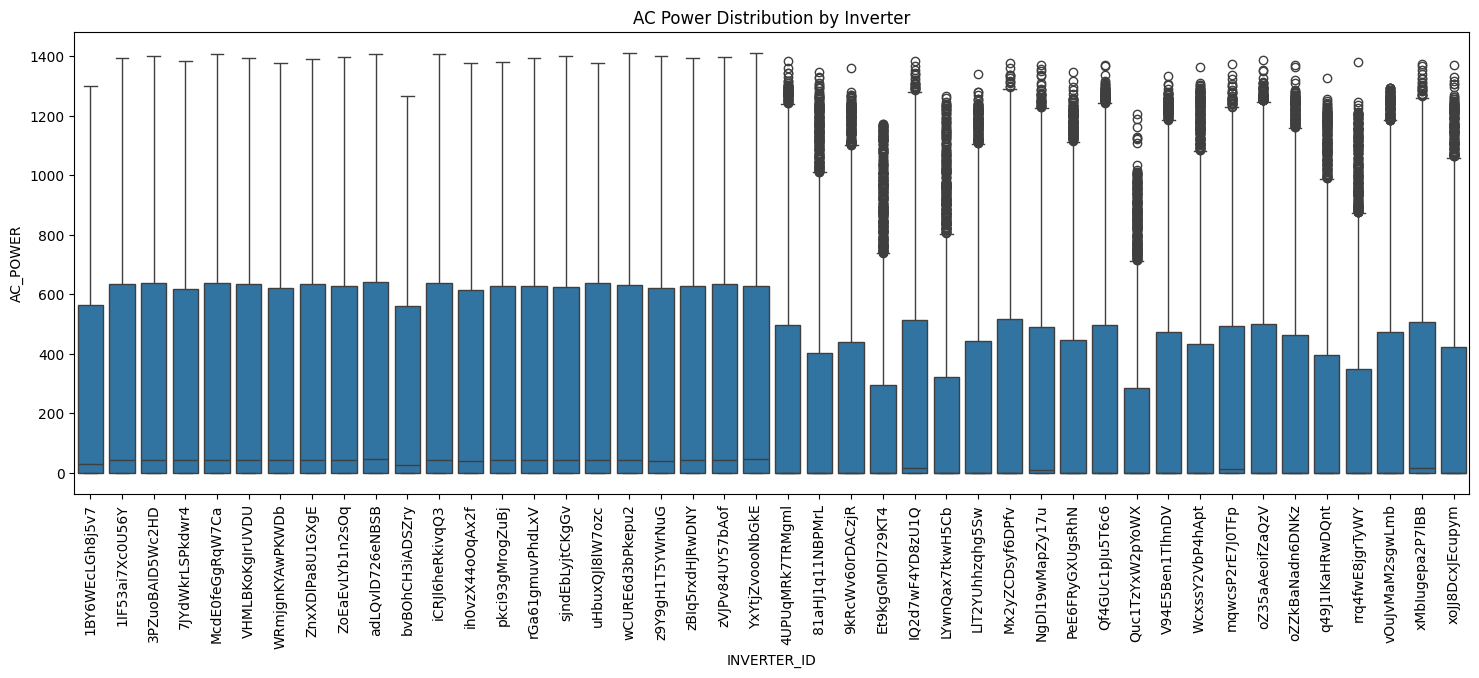

In [ ]:
plt.figure(figsize=(18,6))

sns.boxplot(
    data=df,
    x="INVERTER_ID",
    y="AC_POWER"
)

plt.xticks(rotation=90)

plt.title("AC Power Distribution by Inverter")

plt.show()

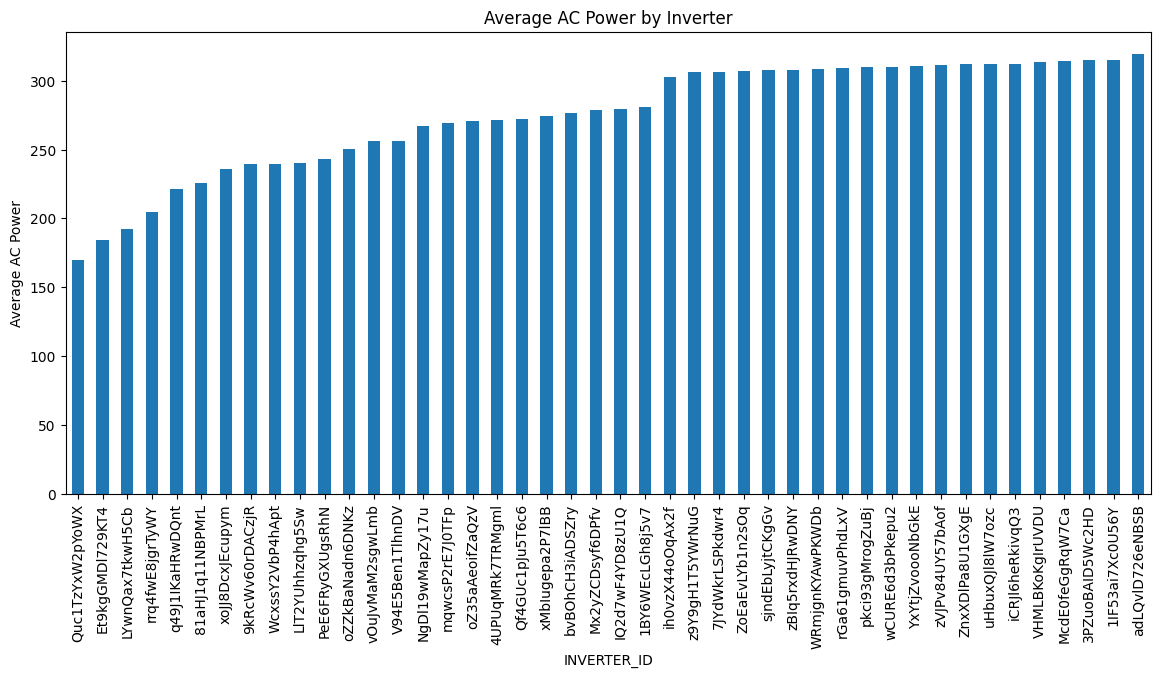

In [ ]:
plt.figure(figsize=(14,6))

(
    df.groupby("INVERTER_ID")["AC_POWER"]
      .mean()
      .sort_values()
      .plot(kind="bar")
)

plt.ylabel("Average AC Power")
plt.title("Average AC Power by Inverter")

plt.show()

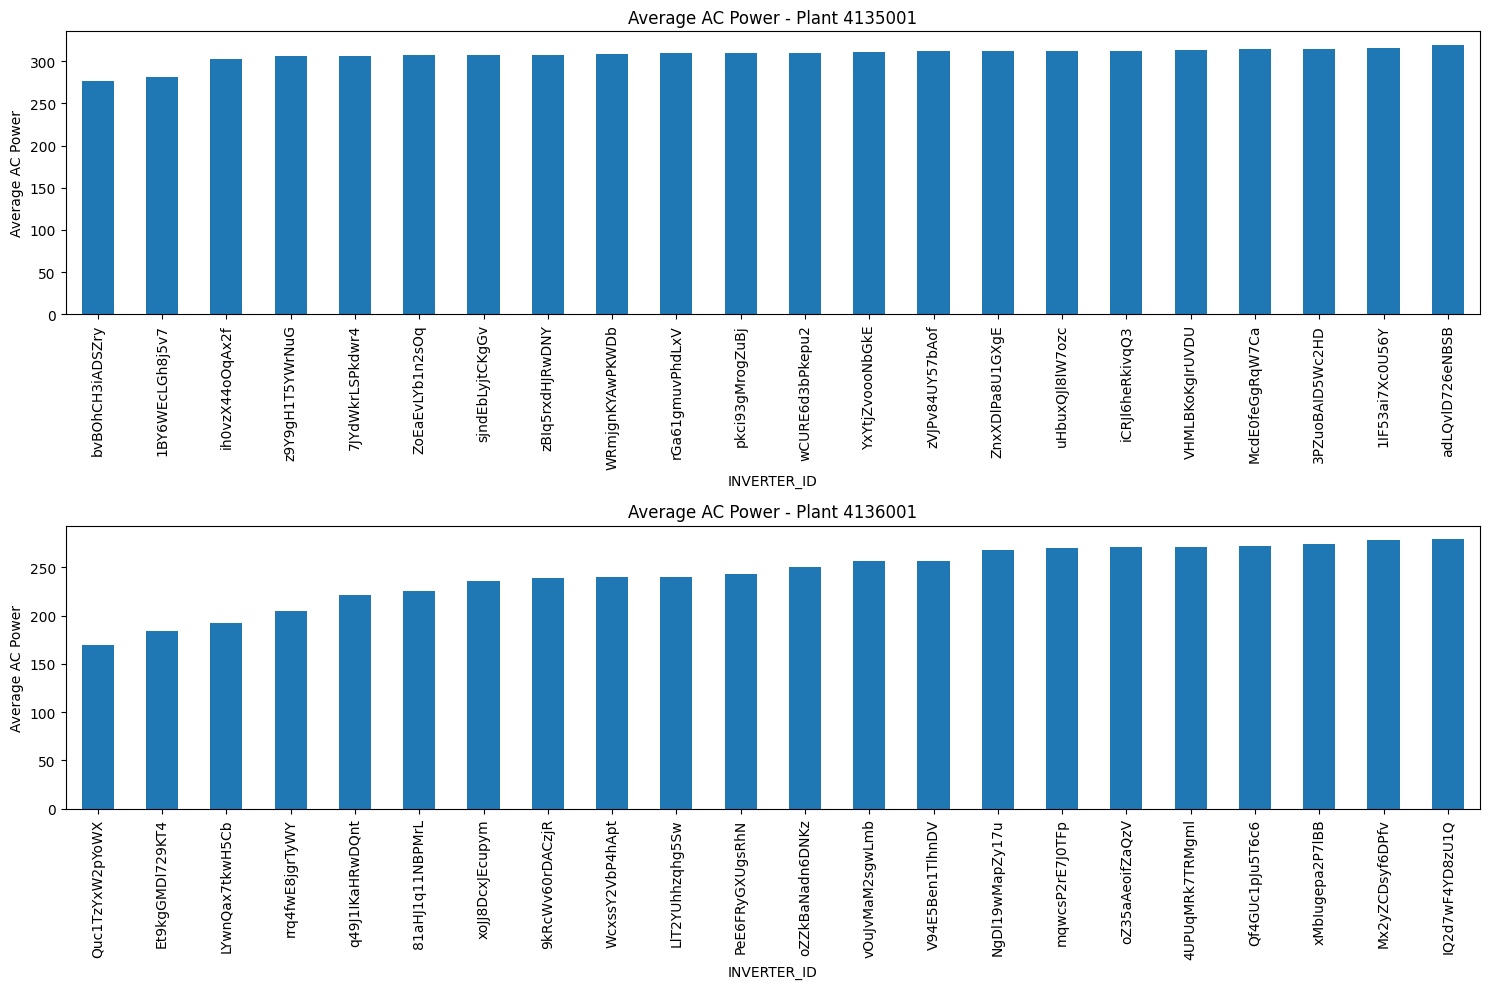

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

for i, plant in enumerate(sorted(df["PLANT_ID"].unique())):
    plant_data = (
        df[df["PLANT_ID"] == plant]
        .groupby("INVERTER_ID")["AC_POWER"]
        .mean()
        .sort_values()
    )

    plant_data.plot(kind="bar", ax=axes[i])

    axes[i].set_title(f"Average AC Power - Plant {plant}")
    axes[i].set_ylabel("Average AC Power")

plt.tight_layout()

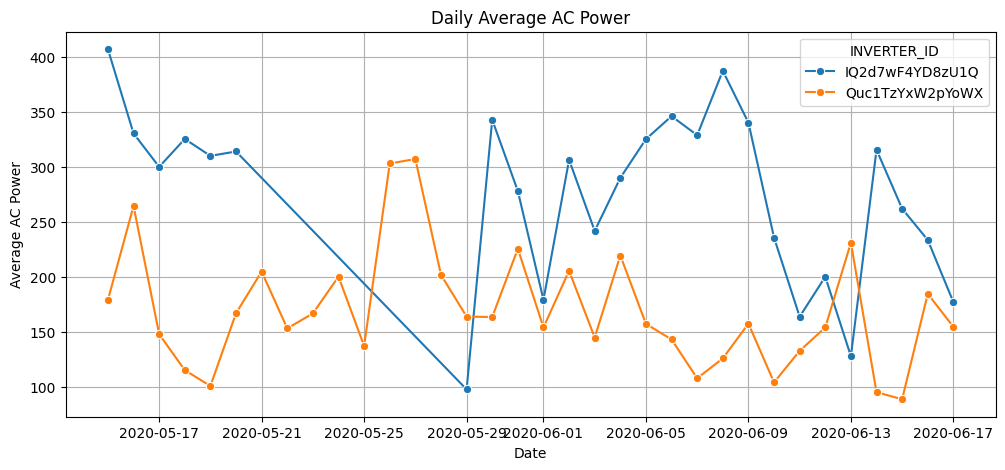

In [ ]:
sample = (
    df[df["INVERTER_ID"].isin([
        "IQ2d7wF4YD8zU1Q",
        "Quc1TzYxW2pYoWX"
    ])]
    .groupby([
        pd.Grouper(key="DATE_TIME", freq="D"),
        "INVERTER_ID"
    ])["AC_POWER"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=sample,
    x="DATE_TIME",
    y="AC_POWER",
    hue="INVERTER_ID",
    marker="o"
)

plt.title("Daily Average AC Power")
plt.xlabel("Date")
plt.ylabel("Average AC Power")
plt.grid(True)

plt.show()

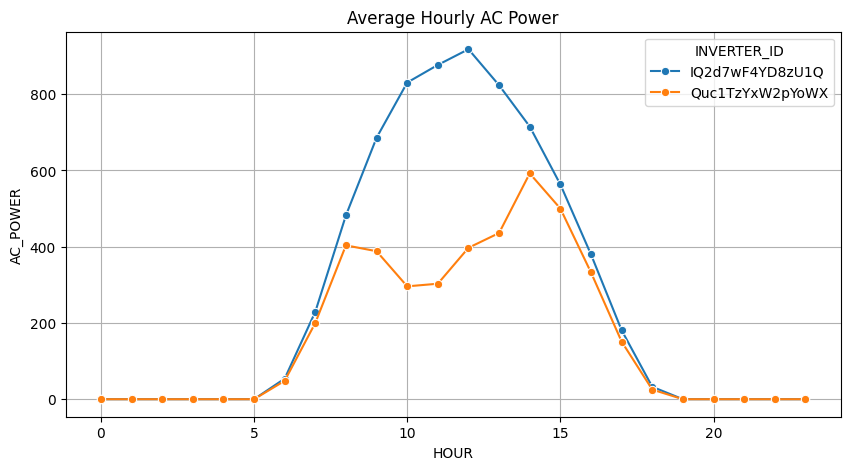

In [ ]:
sample = df[df["INVERTER_ID"].isin([
    "IQ2d7wF4YD8zU1Q",
    "Quc1TzYxW2pYoWX"
])].copy()

sample["HOUR"] = sample["DATE_TIME"].dt.hour

hourly = (
    sample.groupby(["HOUR","INVERTER_ID"])["AC_POWER"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=hourly,
    x="HOUR",
    y="AC_POWER",
    hue="INVERTER_ID",
    marker="o"
)

plt.title("Average Hourly AC Power")

plt.grid(True)

plt.show()

No data of inverter rating is available. So, we cannot conclude whether the issue with the reduced production is within the inverter.

In [ ]:
plant_avg = df.groupby("PLANT_ID")["AC_POWER"].mean()

inv_avg = (
    df.groupby(["PLANT_ID", "INVERTER_ID"])["AC_POWER"]
      .mean()
      .reset_index(name="INV_AVG_AC")
)

inv_avg["PLANT_AVG_AC"] = inv_avg["PLANT_ID"].map(plant_avg)

inv_avg["DIFFERENCE"] = (
    inv_avg["INV_AVG_AC"] - inv_avg["PLANT_AVG_AC"]
)

inv_avg["DIFFERENCE_%"] = (
    inv_avg["DIFFERENCE"] /
    inv_avg["PLANT_AVG_AC"] * 100
).round(2)

inv_avg.sort_values(["PLANT_ID","DIFFERENCE_%"])

,PLANT_ID,INVERTER_ID,INV_AVG_AC,PLANT_AVG_AC,DIFFERENCE,DIFFERENCE_%
11,4135001,bvBOhCH3iADSZry,276.778938,307.778375,-30.999437,-10.07
0,4135001,1BY6WEcLGh8j5v7,281.124073,307.778375,-26.654303,-8.66
13,4135001,ih0vzX44oOqAx2f,302.962438,307.778375,-4.815938,-1.56
19,4135001,z9Y9gH1T5YWrNuG,306.341207,307.778375,-1.437168,-0.47
3,4135001,7JYdWkrLSPkdwr4,306.385671,307.778375,-1.392704,-0.45
9,4135001,ZoEaEvLYb1n2sOq,306.980623,307.778375,-0.797753,-0.26
16,4135001,sjndEbLyjtCKgGv,307.912265,307.778375,0.133890,0.04
20,4135001,zBIq5rxdHJRwDNY,307.925344,307.778375,0.146968,0.05
6,4135001,WRmjgnKYAwPKWDb,308.575465,307.778375,0.797089,0.26
15,4135001,rGa61gmuvPhdLxV,309.345658,307.778375,1.567282,0.51


In [ ]:
import numpy as np

df["EFFICIENCY"] = np.where(
    df["IRRADIATION"] > 0,
    df["AC_POWER"] / df["IRRADIATION"],
    np.nan
)

eff = (
    df.groupby(["PLANT_ID","INVERTER_ID"])["EFFICIENCY"]
      .mean()
      .sort_values()
)

print(eff)

PLANT_ID  INVERTER_ID    
4136001   Quc1TzYxW2pYoWX     847.326785
          Et9kgGMDl729KT4     929.785669
          LYwnQax7tkwH5Cb     978.380157
          rrq4fwE8jgrTyWY     997.503081
          81aHJ1q11NBPMrL    1045.213164
          q49J1IKaHRwDQnt    1053.402850
          WcxssY2VbP4hApt    1078.570096
          xoJJ8DcxJEcupym    1092.239141
          LlT2YUhhzqhg5Sw    1093.022917
          PeE6FRyGXUgsRhN    1094.158386
          9kRcWv60rDACzjR    1099.832621
          oZZkBaNadn6DNKz    1133.864413
          V94E5Ben1TlhnDV    1136.124483
          vOuJvMaM2sgwLmb    1153.427986
4135001   bvBOhCH3iADSZry    1170.300539
4136001   Qf4GUc1pJu5T6c6    1180.114023
          4UPUqMRk7TRMgml    1188.197210
4135001   1BY6WEcLGh8j5v7    1188.210050
4136001   oZ35aAeoifZaQzV    1190.378705
          Mx2yZCDsyf6DPfv    1206.173270
          NgDl19wMapZy17u    1222.581514
          mqwcsP2rE7J0TFp    1238.437647
          xMbIugepa2P7lBB    1241.816923
          IQ2d7wF4YD8zU1Q    12

In [ ]:
eff = (
    df.groupby(["PLANT_ID","INVERTER_ID"])["EFFICIENCY"]
      .mean()
      .sort_values()
)

plant_eff = df.groupby("PLANT_ID")["EFFICIENCY"].mean()

eff = eff.reset_index()

eff["PLANT_AVG"] = eff["PLANT_ID"].map(plant_eff)

eff["STATUS"] = np.where(
    eff["EFFICIENCY"] <
    0.9 * eff["PLANT_AVG"],
    "Needs Inspection",
    "Normal"
)

print(eff)

    PLANT_ID      INVERTER_ID   EFFICIENCY    PLANT_AVG            STATUS
0    4136001  Quc1TzYxW2pYoWX   847.326785  1105.235366  Needs Inspection
1    4136001  Et9kgGMDl729KT4   929.785669  1105.235366  Needs Inspection
2    4136001  LYwnQax7tkwH5Cb   978.380157  1105.235366  Needs Inspection
3    4136001  rrq4fwE8jgrTyWY   997.503081  1105.235366            Normal
4    4136001  81aHJ1q11NBPMrL  1045.213164  1105.235366            Normal
5    4136001  q49J1IKaHRwDQnt  1053.402850  1105.235366            Normal
6    4136001  WcxssY2VbP4hApt  1078.570096  1105.235366            Normal
7    4136001  xoJJ8DcxJEcupym  1092.239141  1105.235366            Normal
8    4136001  LlT2YUhhzqhg5Sw  1093.022917  1105.235366            Normal
9    4136001  PeE6FRyGXUgsRhN  1094.158386  1105.235366            Normal
10   4136001  9kRcWv60rDACzjR  1099.832621  1105.235366            Normal
11   4136001  oZZkBaNadn6DNKz  1133.864413  1105.235366            Normal
12   4136001  V94E5Ben1TlhnDV  1136.12

In [ ]:
daily = (
    df.groupby([
        pd.Grouper(key="DATE_TIME",freq="D"),
        "INVERTER_ID"
    ])["AC_POWER"]
      .mean()
      .reset_index()
)

print(daily)

      DATE_TIME      INVERTER_ID    AC_POWER
0    2020-05-15  1BY6WEcLGh8j5v7  247.812372
1    2020-05-15  1IF53ai7Xc0U56Y  301.705782
2    2020-05-15  3PZuoBAID5Wc2HD  296.877360
3    2020-05-15  4UPUqMRk7TRMgml  176.253459
4    2020-05-15  7JYdWkrLSPkdwr4  292.070366
...         ...              ...         ...
1459 2020-06-17  xMbIugepa2P7lBB  175.629008
1460 2020-06-17  xoJJ8DcxJEcupym  179.984494
1461 2020-06-17  z9Y9gH1T5YWrNuG  247.666683
1462 2020-06-17  zBIq5rxdHJRwDNY  248.710650
1463 2020-06-17  zVJPv84UY57bAof  252.889814

[1464 rows x 3 columns]


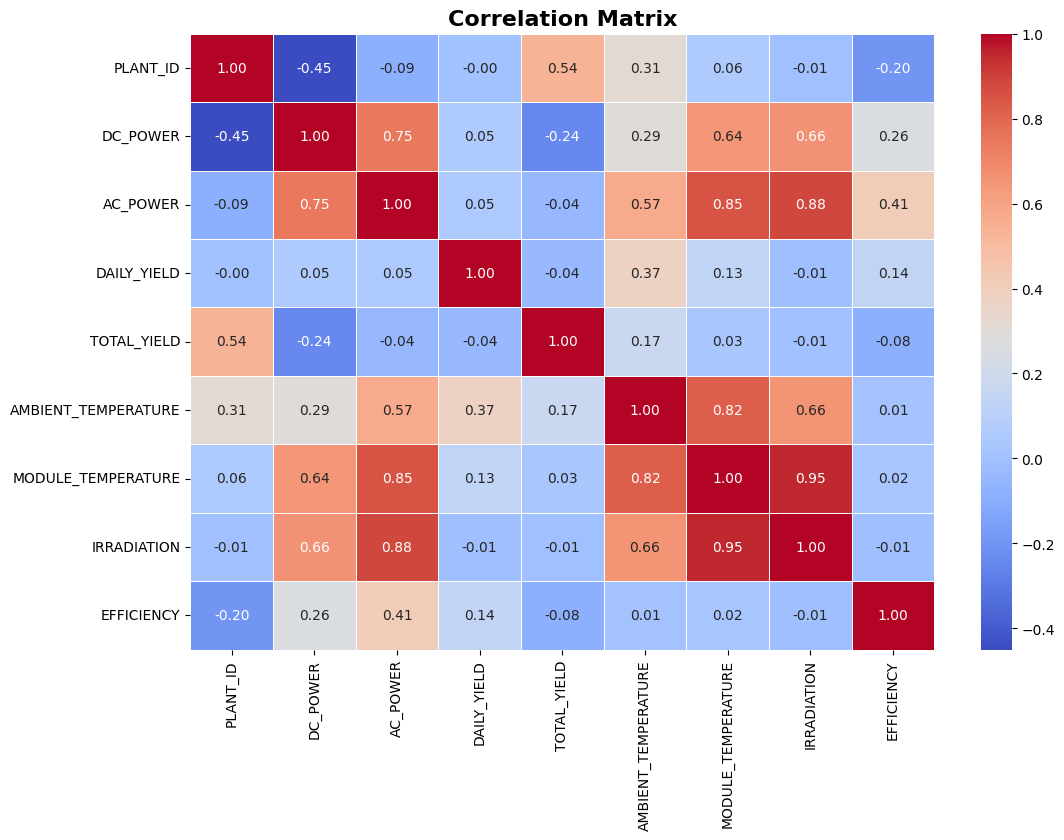

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=16, fontweight="bold")

plt.show()

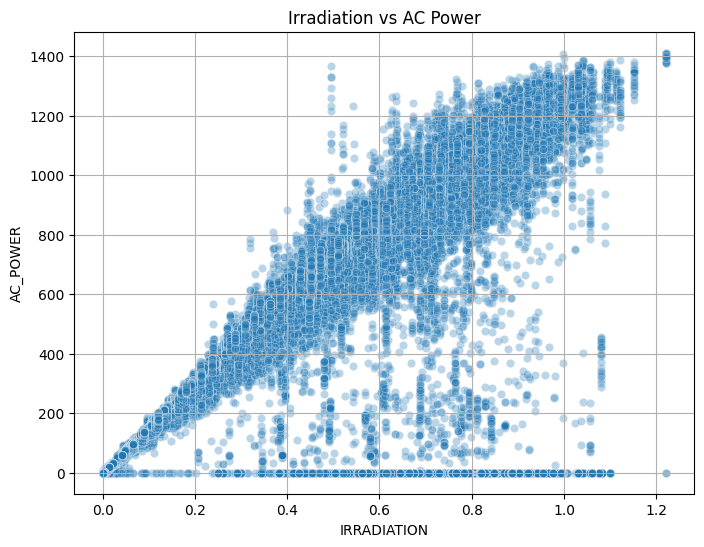

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="IRRADIATION",
    y="AC_POWER",
    alpha=0.3
)

plt.title("Irradiation vs AC Power")
plt.grid(True)

plt.show()

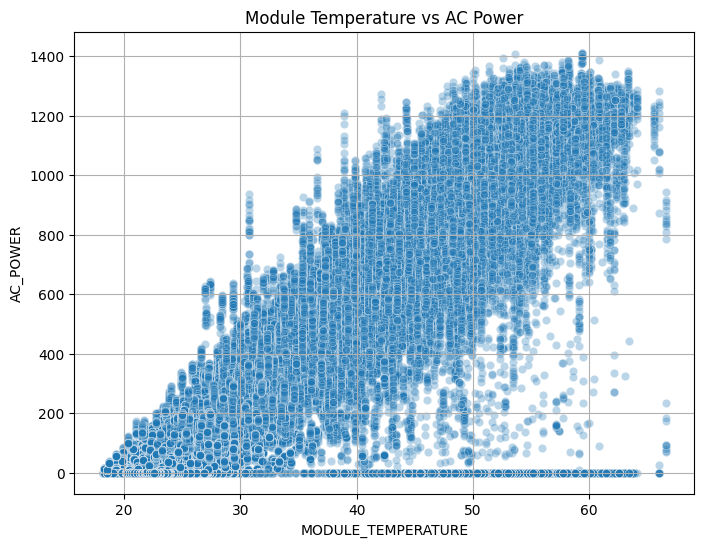

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="MODULE_TEMPERATURE",
    y="AC_POWER",
    alpha=0.3
)

plt.title("Module Temperature vs AC Power")
plt.grid(True)

plt.show()

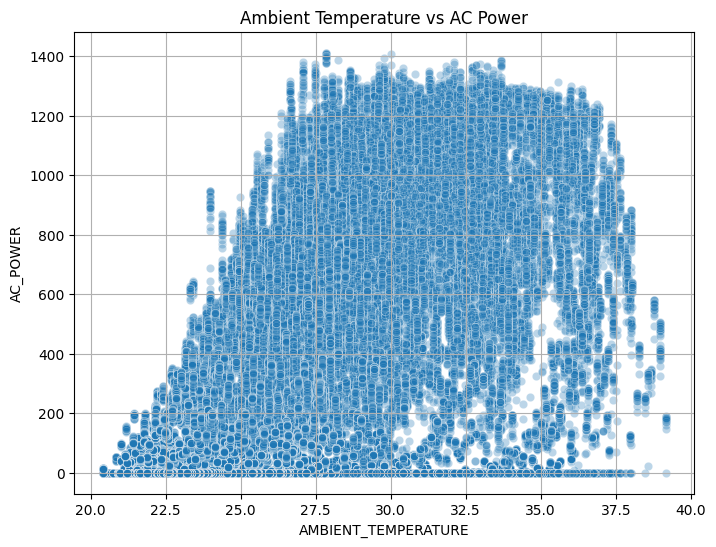

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="AMBIENT_TEMPERATURE",
    y="AC_POWER",
    alpha=0.3
)

plt.title("Ambient Temperature vs AC Power")
plt.grid(True)

plt.show()

In [ ]:
df["HOUR"] = df["DATE_TIME"].dt.hour
df["DAY"] = df["DATE_TIME"].dt.day
df["MONTH"] = df["DATE_TIME"].dt.month
df["WEEKDAY"] = df["DATE_TIME"].dt.day_name()

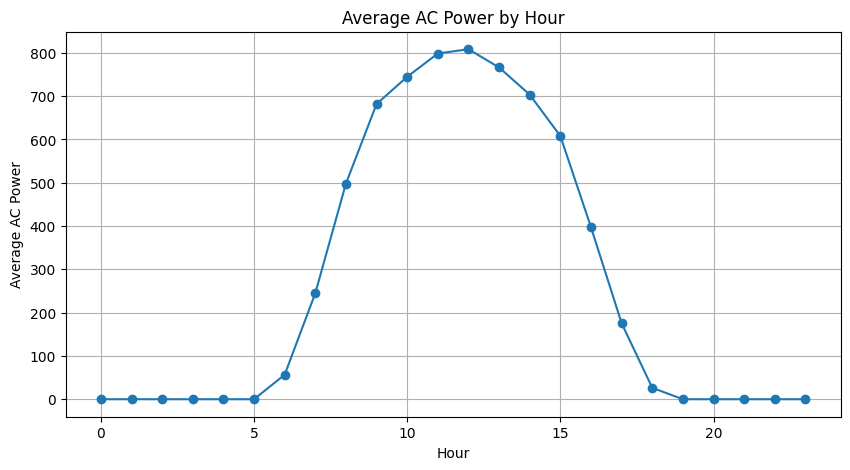

In [ ]:
plt.figure(figsize=(10,5))

hourly = df.groupby("HOUR")["AC_POWER"].mean()

hourly.plot(marker="o")

plt.title("Average AC Power by Hour")
plt.xlabel("Hour")
plt.ylabel("Average AC Power")
plt.grid(True)

plt.show()

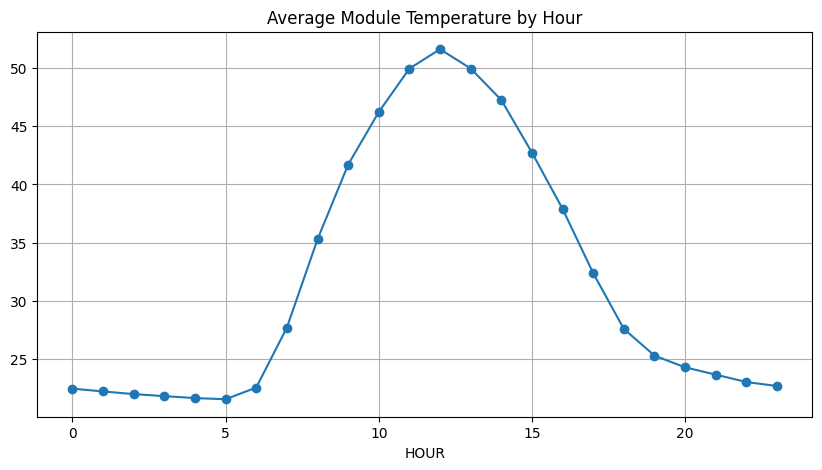

In [ ]:
plt.figure(figsize=(10,5))

module = df.groupby("HOUR")["MODULE_TEMPERATURE"].mean()

module.plot(marker="o")

plt.title("Average Module Temperature by Hour")
plt.grid(True)

plt.show()

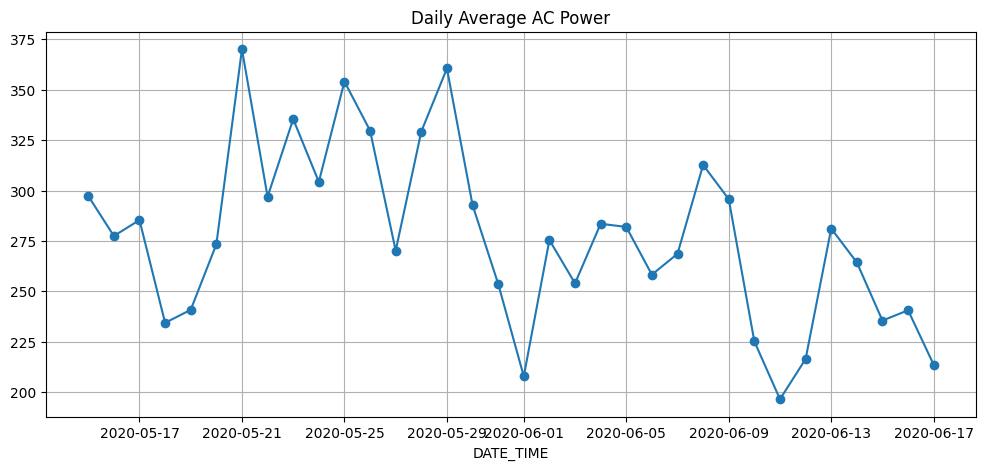

In [ ]:
daily = df.groupby(df["DATE_TIME"].dt.date)["AC_POWER"].mean()

plt.figure(figsize=(12,5))

daily.plot(marker="o")

plt.title("Daily Average AC Power")

plt.grid(True)

plt.show()

**Starting ML Model Building through feature engineering**

In [ ]:
df["YEAR"] = df["DATE_TIME"].dt.year
df["MONTH"] = df["DATE_TIME"].dt.month
df["DAY"] = df["DATE_TIME"].dt.day
df["DAYOFWEEK"] = df["DATE_TIME"].dt.dayofweek
df["HOUR"] = df["DATE_TIME"].dt.hour
df["MINUTE"] = df["DATE_TIME"].dt.minute

In [ ]:
import numpy as np

df["HOUR_SIN"] = np.sin(2 * np.pi * df["HOUR"] / 24)
df["HOUR_COS"] = np.cos(2 * np.pi * df["HOUR"] / 24)

In [ ]:
df["TEMP_DIFF"] = (
    df["MODULE_TEMPERATURE"] - df["AMBIENT_TEMPERATURE"]
)

In [ ]:
df = df.sort_values(["INVERTER_ID", "DATE_TIME"])

df["AC_POWER_LAG_1"] = (
    df.groupby("INVERTER_ID")["AC_POWER"].shift(1)
)

df["AC_POWER_LAG_2"] = (
    df.groupby("INVERTER_ID")["AC_POWER"].shift(2)
)

df["AC_POWER_LAG_4"] = (
    df.groupby("INVERTER_ID")["AC_POWER"].shift(4)
)

In [ ]:
df["ROLLING_MEAN_4"] = (
    df.groupby("INVERTER_ID")["AC_POWER"].transform(lambda x: x.rolling(4).mean())
)

df["ROLLING_STD_4"] = (
    df.groupby("INVERTER_ID")["AC_POWER"].transform(lambda x: x.rolling(4).std())
)

In [ ]:
drop_cols = [
    "DATE_TIME",
    "AC_POWER",
    "DAILY_YIELD",
    "TOTAL_YIELD"
]

In [ ]:
features_model1 = [
    "PLANT_ID",
    "DC_POWER",
    "IRRADIATION",
    "MODULE_TEMPERATURE",
    "AMBIENT_TEMPERATURE",
    "HOUR",
    "DAY",
    "MONTH",
    "DAYOFWEEK",
    "HOUR_SIN",
    "HOUR_COS",
    "TEMP_DIFF",
    "INVERTER_ID"
]

In [ ]:
features_model2 = [
    "PLANT_ID",
    "IRRADIATION",
    "MODULE_TEMPERATURE",
    "AMBIENT_TEMPERATURE",
    "HOUR",
    "DAY",
    "MONTH",
    "DAYOFWEEK",
    "HOUR_SIN",
    "HOUR_COS",
    "TEMP_DIFF",
    "INVERTER_ID"
]

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["INVERTER_ID"] = le.fit_transform(df["INVERTER_ID"])

In [ ]:
df.isnull().sum().sum()

np.int64(59946)

In [ ]:
target = "AC_POWER"

df_model1 = df[
    features_model1 + [target] + ["DATE_TIME"]
].dropna()

In [ ]:
df.isnull().sum().sum()

np.int64(59946)

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
EFFICIENCY,59374
AC_POWER_LAG_4,176
ROLLING_MEAN_4,132
ROLLING_STD_4,132
AC_POWER_LAG_2,88
AC_POWER_LAG_1,44
AC_POWER,0
DC_POWER,0
DATE_TIME,0
PLANT_ID,0


In [ ]:
df = df.drop(columns=[
    "EFFICIENCY",
    "AC_POWER_LAG_1",
    "AC_POWER_LAG_2",
    "AC_POWER_LAG_4",
    "ROLLING_MEAN_4",
    "ROLLING_STD_4"
])

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
split_date = "2020-06-11"

train = df[df["DATE_TIME"] < split_date]
test = df[df["DATE_TIME"] >= split_date]

In [ ]:
X_train_model1 = train[features_model1]
y_train_model1 = train[target]

X_test_model1 = test[features_model1]
y_test_model1 = test[target]

In [ ]:
X_train_model2 = train[features_model2]
y_train_model2 = train[target]

X_test_model2 = test[features_model2]
y_test_model2 = test[target]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler1 = StandardScaler()

X_train_model1_scaled = scaler1.fit_transform(X_train_model1)
X_test_model1_scaled = scaler1.transform(X_test_model1)

In [ ]:
scaler2 = StandardScaler()

X_train_model2_scaled = scaler2.fit_transform(X_train_model2)
X_test_model2_scaled = scaler2.transform(X_test_model2)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model1 = LinearRegression()
lr_model1.fit(X_train_model1_scaled, y_train_model1)

pred_lr = lr_model1.predict(X_test_model1_scaled)

mae_lr = mean_absolute_error(y_test_model1, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_model1, pred_lr))
r2_lr = r2_score(y_test_model1, pred_lr)

print("Linear Regression")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression
MAE : 55.12858656323875
RMSE: 112.69952528580666
R²  : 0.87918578953072


In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt_model1 = DecisionTreeRegressor(
    random_state=42,
    max_depth=15,
    min_samples_leaf=5
)

dt_model1.fit(X_train_model1, y_train_model1)

pred_dt = dt_model1.predict(X_test_model1)

mae_dt = mean_absolute_error(y_test_model1, pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test_model1, pred_dt))
r2_dt = r2_score(y_test_model1, pred_dt)

print("Decision Tree")
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R²  :", r2_dt)

Decision Tree
MAE : 0.7525890376975557
RMSE: 4.689586285208167
R²  : 0.9997908090420692


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model1 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model1.fit(X_train_model1, y_train_model1)

pred_rf = rf_model1.predict(X_test_model1)

mae_rf = mean_absolute_error(y_test_model1, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_model1, pred_rf))
r2_rf = r2_score(y_test_model1, pred_rf)

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest
MAE : 0.5648622849109531
RMSE: 3.3006024980788546
R²  : 0.9998963760137871


In [ ]:
from xgboost import XGBRegressor

xgb_model1 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

xgb_model1.fit(X_train_model1, y_train_model1)

pred_xgb = xgb_model1.predict(X_test_model1)

mae_xgb = mean_absolute_error(y_test_model1, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_model1, pred_xgb))
r2_xgb = r2_score(y_test_model1, pred_xgb)

print("XGBoost")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

XGBoost
MAE : 2.4869920440270508
RMSE: 5.0826672066225855
R²  : 0.9997542705570758


In [ ]:
from lightgbm import LGBMRegressor

lgb_model1 = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgb_model1.fit(X_train_model1, y_train_model1)

pred_lgb = lgb_model1.predict(X_test_model1)

mae_lgb = mean_absolute_error(y_test_model1, pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test_model1, pred_lgb))
r2_lgb = r2_score(y_test_model1, pred_lgb)

print("LightGBM")
print("MAE :", mae_lgb)
print("RMSE:", rmse_lgb)
print("R²  :", r2_lgb)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005394 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1424
[LightGBM] [Info] Number of data points in the train set: 106948, number of used features: 13
[LightGBM] [Info] Start training from score 285.642300
LightGBM
MAE : 2.72389566158654
RMSE: 5.756805441457102
R²  : 0.9996847631704412


In [ ]:
from catboost import CatBoostRegressor

cat_model1 = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    verbose=0,
    random_state=42
)

cat_model1.fit(X_train_model1, y_train_model1)

pred_cat = cat_model1.predict(X_test_model1)

mae_cat = mean_absolute_error(y_test_model1, pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test_model1, pred_cat))
r2_cat = r2_score(y_test_model1, pred_cat)

print("CatBoost")
print("MAE :", mae_cat)
print("RMSE:", rmse_cat)
print("R²  :", r2_cat)

CatBoost
MAE : 5.253271440105067
RMSE: 9.696643773443792
R²  : 0.9991056310176036


In [ ]:
results_model1 = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],
    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf,
        mae_xgb,
        mae_lgb,
        mae_cat
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_xgb,
        rmse_lgb,
        rmse_cat
    ],
    "R²": [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_xgb,
        r2_lgb,
        r2_cat
    ]
})

results_model1.sort_values("RMSE")

,Model,MAE,RMSE,R²
2,Random Forest,0.564862,3.300602,0.999896
1,Decision Tree,0.752589,4.689586,0.999791
3,XGBoost,2.486992,5.082667,0.999754
4,LightGBM,2.723896,5.756805,0.999685
5,CatBoost,5.253271,9.696644,0.999106
0,Linear Regression,55.128587,112.699525,0.879186


MODEL 2 - same data without lag features

In [ ]:
lr_model2a = LinearRegression()
lr_model2a.fit(X_train_model2_scaled, y_train_model2)

pred_lr_m2 = lr_model2a.predict(X_test_model2_scaled)

mae_lr_m2 = mean_absolute_error(y_test_model2, pred_lr_m2)
rmse_lr_m2 = np.sqrt(mean_squared_error(y_test_model2, pred_lr_m2))
r2_lr_m2 = r2_score(y_test_model2, pred_lr_m2)

print("Linear Regression")
print("MAE :", mae_lr_m2)
print("RMSE:", rmse_lr_m2)
print("R²  :", r2_lr_m2)

Linear Regression
MAE : 73.54158421829972
RMSE: 131.79741442249622
R²  : 0.8347704852044836


In [ ]:
dt_model2a = DecisionTreeRegressor(
    random_state=42,
    max_depth=15,
    min_samples_leaf=5
)

dt_model2a.fit(X_train_model2, y_train_model2)

pred_dt2 = dt_model2a.predict(X_test_model2)

mae_dt_m2 = mean_absolute_error(y_test_model2, pred_dt2)
rmse_dt_m2 = np.sqrt(mean_squared_error(y_test_model2, pred_dt2))
r2_dt_m2 = r2_score(y_test_model2, pred_dt2)

print("Decision Tree")
print("MAE :", mae_dt_m2)
print("RMSE:", rmse_dt_m2)
print("R²  :", r2_dt_m2)

Decision Tree
MAE : 41.637419523641114
RMSE: 137.52910638630436
R²  : 0.8200867748305538


In [ ]:
rf_model2a = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model2a.fit(X_train_model2, y_train_model2)

pred_rf2 = rf_model2a.predict(X_test_model2)

mae_rf_m2 = mean_absolute_error(y_test_model2, pred_rf2)
rmse_rf_m2 = np.sqrt(mean_squared_error(y_test_model2, pred_rf2))
r2_rf_m2 = r2_score(y_test_model2, pred_rf2)

print("Random Forest")
print("MAE :", mae_rf_m2)
print("RMSE:", rmse_rf_m2)
print("R²  :", r2_rf_m2)

Random Forest
MAE : 37.08733720890625
RMSE: 124.86622633655803
R²  : 0.8516922588415446


In [ ]:
xgb_model2a = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

xgb_model2a.fit(X_train_model2, y_train_model2)

pred_xgb2 = xgb_model2a.predict(X_test_model2)

mae_xgb_m2 = mean_absolute_error(y_test_model2, pred_xgb2)
rmse_xgb_m2 = np.sqrt(mean_squared_error(y_test_model2, pred_xgb2))
r2_xgb_m2 = r2_score(y_test_model2, pred_xgb2)

print("XGBoost")
print("MAE :", mae_xgb_m2)
print("RMSE:", rmse_xgb_m2)
print("R²  :", r2_xgb_m2)

XGBoost
MAE : 37.942587797689065
RMSE: 126.61764878836105
R²  : 0.8475026362457556


In [ ]:
lgb_model_2a = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgb_model_2a.fit(X_train_model2, y_train_model2)

pred_lgb2 = lgb_model_2a.predict(X_test_model2)

mae_lgb_m2 = mean_absolute_error(y_test_model2, pred_lgb2)
rmse_lgb_m2 = np.sqrt(mean_squared_error(y_test_model2, pred_lgb2))
r2_lgb_m2 = r2_score(y_test_model2, pred_lgb2)

print("LightGBM")
print("MAE :", mae_lgb_m2)
print("RMSE:", rmse_lgb_m2)
print("R²  :", r2_lgb_m2)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025491 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1169
[LightGBM] [Info] Number of data points in the train set: 106948, number of used features: 12
[LightGBM] [Info] Start training from score 285.642300
LightGBM
MAE : 37.63540251783936
RMSE: 123.09161134187397
R²  : 0.8558778406414946


In [ ]:
cat_model2a = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    verbose=0,
    random_state=42
)

cat_model2a.fit(X_train_model2, y_train_model2)

pred_cat2 = cat_model2a.predict(X_test_model2)

mae_cat_m2 = mean_absolute_error(y_test_model2, pred_cat2)
rmse_cat_m2 = np.sqrt(mean_squared_error(y_test_model2, pred_cat2))
r2_cat_m2 = r2_score(y_test_model2, pred_cat2)

print("CatBoost")
print("MAE :", mae_cat_m2)
print("RMSE:", rmse_cat_m2)
print("R²  :", r2_cat_m2)

CatBoost
MAE : 41.04993676993413
RMSE: 119.73005966536603
R²  : 0.8636421187338947


In [ ]:
results_model2a = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],
    "MAE": [
        mae_lr_m2,
        mae_dt_m2,
        mae_rf_m2,
        mae_xgb_m2,
        mae_lgb_m2,
        mae_cat_m2
    ],
    "RMSE": [
        rmse_lr_m2,
        rmse_dt_m2,
        rmse_rf_m2,
        rmse_xgb_m2,
        rmse_lgb_m2,
        rmse_cat_m2
    ],
    "R²": [
        r2_lr_m2,
        r2_dt_m2,
        r2_rf_m2,
        r2_xgb_m2,
        r2_lgb_m2,
        r2_cat_m2
    ]
})

results_model2a.sort_values("RMSE")

,Model,MAE,RMSE,R²
5,CatBoost,41.049937,119.730060,0.863642
4,LightGBM,37.635403,123.091611,0.855878
2,Random Forest,37.087337,124.866226,0.851692
3,XGBoost,37.942588,126.617649,0.847503
0,Linear Regression,73.541584,131.797414,0.834770
1,Decision Tree,41.637420,137.529106,0.820087


**REBUILDING MODEL2 with LAG features**

In [ ]:
df["EFFICIENCY"] = (df["AC_POWER"] / df["DC_POWER"]).replace([np.inf, -np.inf], np.nan)

In [ ]:
df = df.sort_values(["INVERTER_ID", "DATE_TIME"])

In [ ]:
df["AC_POWER_LAG_1"] = df.groupby("INVERTER_ID")["AC_POWER"].shift(1)

df["AC_POWER_LAG_2"] = df.groupby("INVERTER_ID")["AC_POWER"].shift(2)

df["AC_POWER_LAG_4"] = df.groupby("INVERTER_ID")["AC_POWER"].shift(4)

In [ ]:
df["ROLLING_MEAN_4"] = (
    df.groupby("INVERTER_ID")["AC_POWER"]
      .transform(lambda x: x.shift(1).rolling(4).mean())
)

df["ROLLING_STD_4"] = (
    df.groupby("INVERTER_ID")["AC_POWER"]
      .transform(lambda x: x.shift(1).rolling(4).std())
)

In [ ]:
df = df.dropna().reset_index(drop=True)

In [ ]:
df.columns

Index(['DATE_TIME', 'PLANT_ID', 'INVERTER_ID', 'DC_POWER', 'AC_POWER',
       'DAILY_YIELD', 'TOTAL_YIELD', 'WEATHER_STATION_ID',
       'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'HOUR',
       'DAY', 'MONTH', 'WEEKDAY', 'YEAR', 'DAYOFWEEK', 'MINUTE', 'HOUR_SIN',
       'HOUR_COS', 'TEMP_DIFF', 'EFFICIENCY', 'AC_POWER_LAG_1',
       'AC_POWER_LAG_2', 'AC_POWER_LAG_4', 'ROLLING_MEAN_4', 'ROLLING_STD_4'],
      dtype='object')

In [ ]:
features_model2b = [
    "PLANT_ID",
    "IRRADIATION",
    "MODULE_TEMPERATURE",
    "AMBIENT_TEMPERATURE",
    "HOUR",
    "DAY",
    "MONTH",
    "DAYOFWEEK",
    "HOUR_SIN",
    "HOUR_COS",
    "TEMP_DIFF",
    "AC_POWER_LAG_1",
    "AC_POWER_LAG_2",
    "AC_POWER_LAG_4",
    "ROLLING_MEAN_4",
    "ROLLING_STD_4",
    "INVERTER_ID"
]

In [ ]:
df_model2b = df[features_model2b + ["AC_POWER", "DATE_TIME"]].dropna().copy()

In [ ]:
split_date = "2020-06-11"

train = df_model2b[df_model2b["DATE_TIME"] < split_date]
test = df_model2b[df_model2b["DATE_TIME"] >= split_date]

In [ ]:
target = "AC_POWER"

X_train_model2b = train[features_model2b]
X_test_model2b = test[features_model2b]

y_train_model2b = train[target]
y_test_model2b = test[target]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_model2b_scaled = scaler.fit_transform(X_train_model2b)
X_test_model2b_scaled = scaler.transform(X_test_model2b)

In [ ]:
lr_model2b = LinearRegression()

lr_model2b.fit(X_train_model2b_scaled, y_train_model2b)

pred_lr_m2b = lr_model2b.predict(X_test_model2b_scaled)

In [ ]:
dt_model2b = DecisionTreeRegressor(
    random_state=42,
    max_depth=15,
    min_samples_leaf=5
)

dt_model2b.fit(X_train_model2b, y_train_model2b)

pred_dt_m2b = dt_model2b.predict(X_test_model2b)

In [ ]:
rf_model2b = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model2b.fit(X_train_model2b, y_train_model2b)

pred_rf_2b = rf_model2b.predict(X_test_model2b)

In [ ]:
xgb_model2b = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)


xgb_model2b.fit(X_train_model2b, y_train_model2b)

pred_xgb_2b = xgb_model2b.predict(X_test_model2b)

In [ ]:
lgb_model_2b = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgb_model_2b.fit(X_train_model2b, y_train_model2b)

pred_lgb_2b = lgb_model_2b.predict(X_test_model2b)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004077 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2421
[LightGBM] [Info] Number of data points in the train set: 53369, number of used features: 17
[LightGBM] [Info] Start training from score 571.189047


In [ ]:
cat_model2b = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    verbose=0,
    random_state=42
)

cat_model2b.fit(X_train_model2b, y_train_model2b)

pred_cat_2b = cat_model2b.predict(X_test_model2b)

In [ ]:
def evaluate(y_true, y_pred):
    return (
        mean_absolute_error(y_true, y_pred),
        np.sqrt(mean_squared_error(y_true, y_pred)),
        r2_score(y_true, y_pred)
    )

mae_lr_2b, rmse_lr_2b, r2_lr_2b = evaluate(y_test_model2b, pred_lr_m2b)
mae_dt_2b, rmse_dt_2b, r2_dt_2b = evaluate(y_test_model2b, pred_dt_m2b)
mae_rf_2b, rmse_rf_2b, r2_rf_2b = evaluate(y_test_model2b, pred_rf_2b)
mae_xgb_2b, rmse_xgb_2b, r2_xgb_2b = evaluate(y_test_model2b, pred_xgb_2b)
mae_lgb_2b, rmse_lgb_2b, r2_lgb_2b = evaluate(y_test_model2b, pred_lgb_2b)
mae_cat_2b, rmse_cat_2b, r2_cat_2b = evaluate(y_test_model2b, pred_cat_2b)

In [ ]:
results_model2b = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],
    "MAE": [
        mae_lr_2b,
        mae_dt_2b,
        mae_rf_2b,
        mae_xgb_2b,
        mae_lgb_2b,
        mae_cat_2b
    ],
    "RMSE": [
        rmse_lr_2b,
        rmse_dt_2b,
        rmse_rf_2b,
        rmse_xgb_2b,
        rmse_lgb_2b,
        rmse_cat_2b
    ],
    "R²": [
        r2_lr_2b,
        r2_dt_2b,
        r2_rf_2b,
        r2_xgb_2b,
        r2_lgb_2b,
        r2_cat_2b
    ]
})

results_model2b.sort_values("RMSE")

,Model,MAE,RMSE,R²
4,LightGBM,34.661793,76.997202,0.942026
5,CatBoost,38.349279,77.571331,0.941158
3,XGBoost,36.088605,78.875912,0.939163
2,Random Forest,42.893820,83.860050,0.931231
0,Linear Regression,45.262846,84.098639,0.930839
1,Decision Tree,52.356435,108.761099,0.884328


In [ ]:
encoded_inverter = le.transform(["adLQvlD726eNBSB"])[0]

print(encoded_inverter)

24




1.   Model 1 : Current AC Power Estimation
2.   Model 2A & 2B : Forecasting future AC power



*   2A - Future weather/time features only
*   2B - Future weather/time + previous AC power (lag features)





In [ ]:
sample = X_test_model1.iloc[[0]]

actual = y_test_model1.iloc[0]

prediction = rf_model1.predict(sample)[0]

print("MODEL 1 - CURRENT POWER ESTIMATION")

print(f"Actual AC Power    : {actual:.2f} kW")
print(f"Predicted AC Power : {prediction:.2f} kW")
print(f"Absolute Error     : {abs(actual-prediction):.2f} kW")

MODEL 1 - CURRENT POWER ESTIMATION
Actual AC Power    : 0.00 kW
Predicted AC Power : 0.00 kW
Absolute Error     : 0.00 kW


In [ ]:
daytime = X_test_model1[y_test_model1 > 100]

sample = daytime.iloc[[0]]

actual = y_test_model1.loc[sample.index[0]].iloc[0]

prediction = rf_model1.predict(sample)[0]

print(f"Actual AC Power    : {actual:.2f} kW")
print(f"Predicted AC Power : {prediction:.2f} kW")
print(f"Absolute Error     : {abs(actual-prediction):.2f} kW")

Actual AC Power    : 108.71 kW
Predicted AC Power : 107.94 kW
Absolute Error     : 0.77 kW


In [ ]:
daytime = X_test_model2[y_test_model2 > 100]

sample = daytime.iloc[[0]]

actual = y_test_model2.loc[sample.index[0]].iloc[0]

prediction = cat_model2a.predict(sample)[0]

print("MODEL 2A - FUTURE POWER FORECASTING")

print(f"Actual AC Power    : {actual:.2f} kW")
print(f"Predicted AC Power : {prediction:.2f} kW")
print(f"Absolute Error     : {abs(actual-prediction):.2f} kW")

MODEL 2A - FUTURE POWER FORECASTING
Actual AC Power    : 108.71 kW
Predicted AC Power : 109.09 kW
Absolute Error     : 0.38 kW


In [ ]:
daytime = X_test_model2b[y_test_model2b > 100]

sample = X_test_model2b.iloc[[0]]

actual = y_test_model2b.iloc[0]

prediction = xgb_model2b.predict(sample)[0]

print("MODEL 2B - FORECASTING WITH LAG FEATURES")

print(f"Actual AC Power    : {actual:.2f} kW")
print(f"Predicted AC Power : {prediction:.2f} kW")
print(f"Absolute Error     : {abs(actual-prediction):.2f} kW")

MODEL 2B - FORECASTING WITH LAG FEATURES
Actual AC Power    : 13.19 kW
Predicted AC Power : 10.82 kW
Absolute Error     : 2.36 kW


In [ ]:
new_data = pd.DataFrame({
    "PLANT_ID":[4135001],
    "IRRADIATION":[0.92],
    "MODULE_TEMPERATURE":[52],
    "AMBIENT_TEMPERATURE":[31],
    "HOUR":[12],
    "DAY":[18],
    "MONTH":[6],
    "DAYOFWEEK":[3],
    "HOUR_SIN":[np.sin(2*np.pi*12/24)],
    "HOUR_COS":[np.cos(2*np.pi*12/24)],
    "TEMP_DIFF":[21],
    "AC_POWER_LAG_1":[1210],
    "AC_POWER_LAG_2":[1202],
    "AC_POWER_LAG_4":[1180],
    "ROLLING_MEAN_4":[1196.75],
    "ROLLING_STD_4":[13.3],
    "INVERTER_ID":[encoded_inverter]
})

In [ ]:
prediction = xgb_model2b.predict(new_data)

print(prediction)

[1214.3302]


Predicted AC Power = 1214.33 kW

In [ ]:
sample = X_test_model2b[(y_test_model2b > 500)].sample(1, random_state=42)

idx = sample.index[0]

prediction = xgb_model2b.predict(sample)[0]
actual = y_test_model2b.loc[idx]

print("Actual :", actual)
print("Predicted :", prediction)
print("Error :", abs(actual - prediction))

Actual : 755.675
Predicted : 745.489
Error : 10.185986328124955


Starting Feature Importance

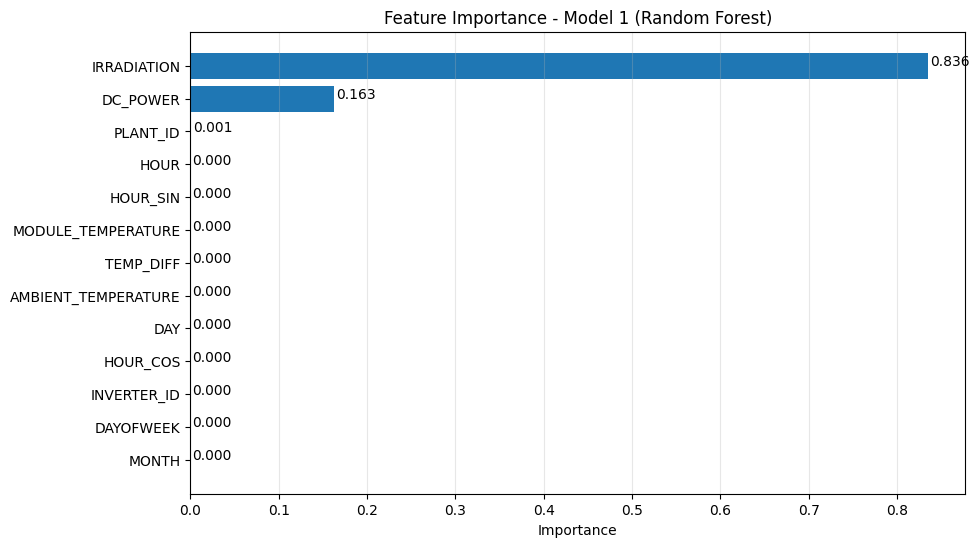

,Feature,Importance
2,IRRADIATION,8.357123e-01
1,DC_POWER,1.630947e-01
0,PLANT_ID,1.060388e-03
5,HOUR,3.126943e-05
9,HOUR_SIN,2.833164e-05
3,MODULE_TEMPERATURE,2.492317e-05
11,TEMP_DIFF,2.103597e-05
4,AMBIENT_TEMPERATURE,1.007490e-05
6,DAY,8.035512e-06
10,HOUR_COS,3.253899e-06


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance_model1 = pd.DataFrame({
    "Feature": features_model1,
    "Importance": rf_model1.feature_importances_
})

importance_model1 = importance_model1.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance_model1["Feature"],
    importance_model1["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance - Model 1 (Random Forest)")
plt.xlabel("Importance")

for i, v in enumerate(importance_model1["Importance"]):
    plt.text(v+0.002, i, f"{v:.3f}")

plt.grid(axis='x', alpha=0.3)

plt.show()

importance_model1

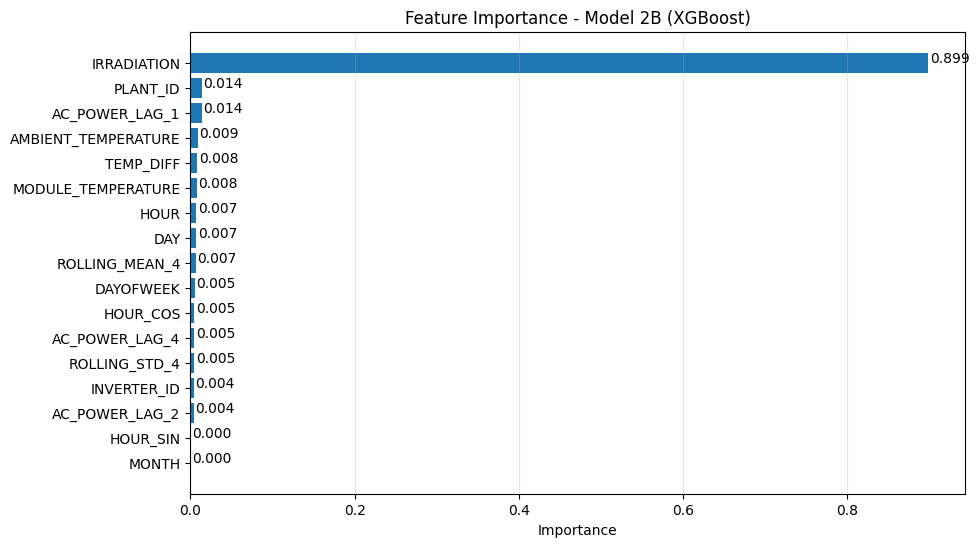

,Feature,Importance
1,IRRADIATION,0.898556
0,PLANT_ID,0.013880
11,AC_POWER_LAG_1,0.013672
3,AMBIENT_TEMPERATURE,0.008958
10,TEMP_DIFF,0.008340
2,MODULE_TEMPERATURE,0.007831
4,HOUR,0.007091
5,DAY,0.007003
14,ROLLING_MEAN_4,0.006775
7,DAYOFWEEK,0.005192


In [ ]:
importance_model2b = pd.DataFrame({
    "Feature": features_model2b,
    "Importance": xgb_model2b.feature_importances_
})

importance_model2b = importance_model2b.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance_model2b["Feature"],
    importance_model2b["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance - Model 2B (XGBoost)")
plt.xlabel("Importance")

for i, v in enumerate(importance_model2b["Importance"]):
    plt.text(v+0.002, i, f"{v:.3f}")

plt.grid(axis='x', alpha=0.3)

plt.show()

importance_model2b

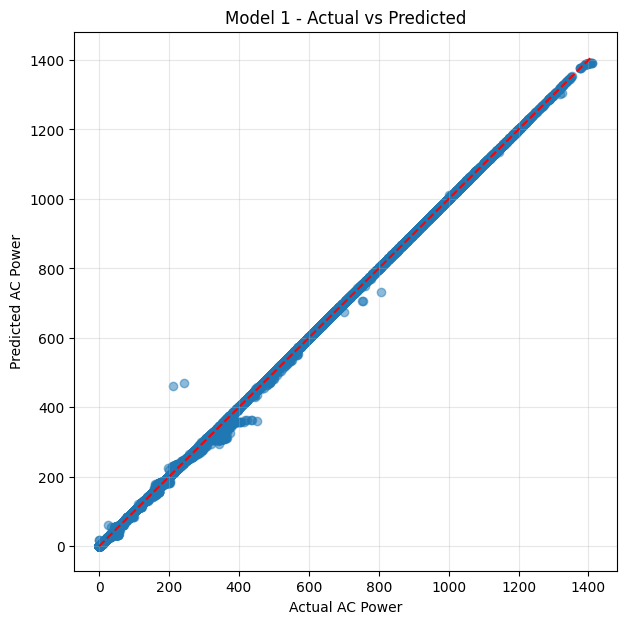

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(y_test_model1, pred_rf, alpha=0.5)

plt.plot(
    [y_test_model1.min(), y_test_model1.max()],
    [y_test_model1.min(), y_test_model1.max()],
    'r--'
)

plt.xlabel("Actual AC Power")
plt.ylabel("Predicted AC Power")
plt.title("Model 1 - Actual vs Predicted")

plt.grid(alpha=0.3)

plt.show()

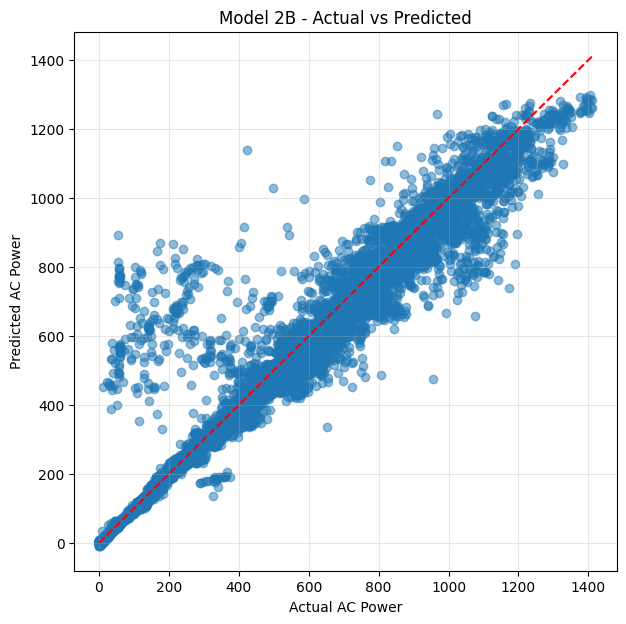

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(y_test_model2b, pred_xgb_2b, alpha=0.5)

plt.plot(
    [y_test_model2b.min(), y_test_model2b.max()],
    [y_test_model2b.min(), y_test_model2b.max()],
    'r--'
)

plt.xlabel("Actual AC Power")
plt.ylabel("Predicted AC Power")
plt.title("Model 2B - Actual vs Predicted")

plt.grid(alpha=0.3)

plt.show()

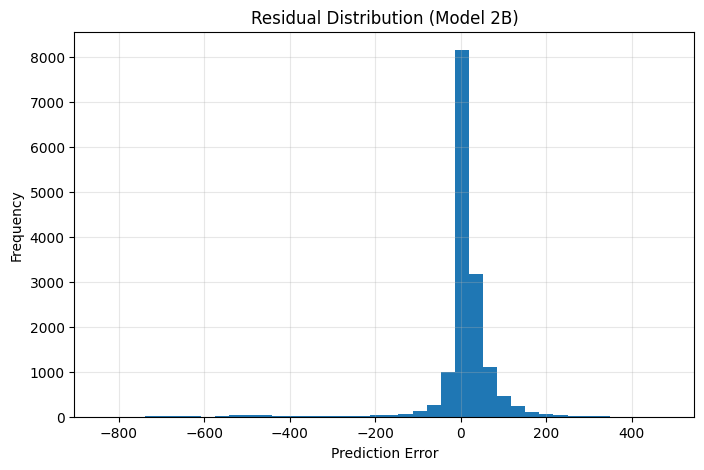

In [ ]:
residuals = y_test_model2b - pred_xgb_2b

plt.figure(figsize=(8,5))

plt.hist(residuals, bins=40)

plt.title("Residual Distribution (Model 2B)")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
import joblib

joblib.dump(rf_model1, "Model1_RandomForest.pkl")

['Model1_RandomForest.pkl']

In [ ]:
joblib.dump(cat_model2a, "Model2A_CatBoost.pkl")

['Model2A_CatBoost.pkl']

In [ ]:
joblib.dump(xgb_model2b, "Model2B_XGBoost.pkl")

['Model2B_XGBoost.pkl']

In [ ]:
df.to_csv("Solar_Power_Final.csv", index=False)

In [ ]:
prediction_df = pd.DataFrame({
    "DATE_TIME": test["DATE_TIME"],
    "PLANT_ID": test["PLANT_ID"],
    "INVERTER_ID": test["INVERTER_ID"],
    "Actual_AC_POWER": y_test_model2b,
    "Predicted_AC_POWER": pred_xgb_2b
})

prediction_df["Error"] = (
    prediction_df["Actual_AC_POWER"]
    - prediction_df["Predicted_AC_POWER"]
)

prediction_df.to_csv(
    "Prediction_Results.csv",
    index=False
)

In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
import os

os.listdir()

['.config',
 'Model2A_CatBoost.pkl',
 'Model2B_XGBoost.pkl',
 'catboost_info',
 'Model1_RandomForest.pkl',
 'Prediction_Results.csv',
 'Solar_Power_Final.csv',
 'sample_data']

In [ ]:
from google.colab import files

files.download("Solar_Power_Final.csv")
files.download("Prediction_Results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>